# Consulta de las tablas del profesor (10 filas cada una)

Tablas del proyecto `prueba-ofr`: FINAGRO_Desembolsos_EFECTIVA, SFC414_DASH y Municipios.CODIGO.

In [ ]:
# Este notebook vive en notebooks/. Las rutas ("datos/...") y los imports
# del paquete pipeline/ se resuelven desde la raiz del repositorio, que es
# la carpeta que contiene main_local.py.
import os
import sys
from pathlib import Path

RAIZ = Path.cwd().resolve()
while not (RAIZ / "main_local.py").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [1]:
# Credencial: cuenta personal trabajodegrado139@gmail.com (queda en cache en ~/.config/pydata)
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pydata_google_auth
from google.cloud import bigquery

credenciales = pydata_google_auth.get_user_credentials(
    ["https://www.googleapis.com/auth/bigquery"], use_local_webserver=True)
client = bigquery.Client(project="prueba-ofr", credentials=credenciales)
pd.set_option("display.max_columns", None)

In [2]:
# SIN COBRO: list_rows usa tabledata.list (como el boton "Preview" de la consola), no ejecuta SQL.
# Un "SELECT * ... LIMIT 10" leeria la tabla completa y la facturaria.
def primeras_filas(tabla, n=10):
    return client.list_rows(tabla, max_results=n).to_dataframe(create_bqstorage_client=False)

In [3]:
finagro = primeras_filas("prueba-ofr.Inclusion_Financiera.FINAGRO_Desembolsos_EFECTIVA")
finagro

,id_credito,fecha_credito,cod_municipio,tipo_cartera,tipo_intermediario,tipo_productor,tipo_beneficiario,tipo_persona,sexo,cod_destino,linea_credito,cadena,eslabon_cadena,valor_credito,valor_inversion,plazo,periodo_gracia,cuotas,cuotas_capital,tasa_indexacion,periodicidad_tasa_indexacion,puntos_adicionales,garantia_fag,nombre_programa,indicador_lec,valor_subsidio,nuevo,viernes,tasa_total,DPNOM,MPIO,DPMP,PDET,region,ruralidad,Destino,Nombre_destino
0,2550303529,2025-08-26,27493,Redescuento,Bancos,Mediano,Desplazados m.p,Natural,Mujer,141430,Inversión,Platano,Producción,5.000000e+07,5.000000e+07,72,2,12,10,IBR,Semestral,1.90,1,IBR FINANCIACIÓN PROYECTOS EJECUTADOS POBLACIÓ...,0,0,1,2025-08-22,0.109367,None,None,None,<NA>,None,None,141430,Plátano
1,2550192894,2025-04-28,27493,Redescuento,Bancos,Pequeño ppib,Desplazado ppib,Natural,Hombre,151370,Inversión,Otros Frutales,Producción,2.670000e+07,2.670000e+07,36,2,6,4,IBR,Semestral,1.90,1,IBR FINANCIACIÓN PROYECTOS EJECUTADOS POBLACIÓ...,0,0,0,2025-04-25,0.110484,None,None,None,<NA>,None,None,151370,Maracuyá
2,2603133346,2026-05-20,05001,Redescuento,Bancos,Grande,Grande productor,Jurídica,NA,104010,Inversión,Porcicultura,Producción,5.000000e+09,5.000000e+09,60,0,60,60,IBR,Mensual,1.48,0,2012 IBR TRANSFORMACION PRODUCTIVA Y SOSTENIBL...,0,0,0,2026-05-15,0.127495,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None
3,2402804071,2024-04-01,05001,Sustitutiva,Bancos,Mediano,Mediano productor,Natural,Hombre,121450,Inversión,Hortalizas,Producción,5.000000e+06,5.000000e+06,12,0,0,0,IBR,Mensual,6.20,0,IBR TARJETA AGROPECUARIA,0,0,0,2024-03-29,0.191326,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,121450,Tomate
4,2102140650,2021-04-06,05001,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NA,129978,Capital de Trabajo,Actividades Complementarias,Producción,2.000000e+07,2.000000e+07,12,0,4,4,DTF,None,7.00,0,CREDITO ROTATIVO EN CONDICIONES FINAGRO,0,0,0,2021-04-02,0.090200,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None
5,2102150675,2021-04-27,05001,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NA,129978,Capital de Trabajo,Actividades Complementarias,Producción,2.000000e+07,1.000000e+08,12,0,4,4,DTF,None,10.00,0,CREDITO ROTATIVO EN CONDICIONES FINAGRO,0,0,0,2021-04-23,0.122889,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None
6,2202386655,2022-06-16,05001,Sustitutiva,Bancos,Mediano,Mediano productor,Jurídica,NA,129978,Capital de Trabajo,Actividades Complementarias,Producción,1.015400e+08,1.015400e+08,1,0,1,1,IBR,Mensual,6.00,0,IBR CREDITO ROTATIVO EN CONDICIONES FINAGRO,0,0,0,2022-06-10,0.132999,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None
7,2202347206,2022-04-06,05001,Sustitutiva,Microfinancieras,Mediano,Mediano productor,Jurídica,NA,129978,Capital de Trabajo,Actividades Complementarias,Producción,3.582051e+06,3.582051e+06,2,0,1,1,IBR,Mensual,9.50,0,IBR FACTORING AGROPECUARIO,0,0,0,2022-04-01,0.155423,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None
8,2202436480,2022-09-15,05001,Sustitutiva,Bancos,Grande,Grande productor,Jurídica,NA,129978,Capital de Trabajo,Actividades Complementarias,Producción,3.300000e+07,3.300000e+07,3,0,3,3,IBR,Mensual,4.00,0,IBR CREDITO ROTATIVO EN CONDICIONES FINAGRO,0,0,0,2022-09-09,0.140568,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None
9,2202423366,2022-08-25,05001,Sustitutiva,Microfinancieras,Mediano,Mediano productor,Jurídica,NA,129978,Capital de Trabajo,Actividades Complementarias,Producción,1.428603e+07,1.428603e+07,2,0,1,1,IBR,Mensual,9.50,0,IBR FACTORING AGROPECUARIO,0,0,0,2022-08-19,0.195972,Antioquia,05001,Medellín,0,Eje cafetero,Ciudades y aglomeraciones,<NA>,None


In [4]:
sfc414 = primeras_filas("prueba-ofr.Inclusion_Financiera.SFC414_DASH")
sfc414

,Fecha_Corte,Tipo_de_persona,Sexo,Tipo_de_credito,Tipo_de_garantia,Montos_desembolsados,Numero_de_creditos_desembolsados,Codigo_Municipio,nombre_departamento,nombre_municipio,region,fecha,ruralidad,Rural_Urbano,Tasa_efectiva_promedio_ponderada_AD,MPIO,PDET_Nom
0,2025-01-31,Natural,No binario,Consumo,Sin garantia,1.316700e+05,3,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,20.735171,05001,NO PDET
1,2026-08-07,Natural,No binario,Consumo,Sin garantia,2.600000e+06,2,05001,Antioquia,Medellín,Eje cafetero,2026,Ciudades y aglomeraciones,Urbano,56.300000,05001,NO PDET
2,2026-05-22,Natural,No binario,Consumo,Garantia idónea o no idónea,1.429007e+08,728,05001,Antioquia,Medellín,Eje cafetero,2026,Ciudades y aglomeraciones,Urbano,20.498690,05001,NO PDET
3,2025-10-17,Natural,No binario,Consumo,Garantia idónea o no idónea,3.308590e+07,20,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,43.338329,05001,NO PDET
4,2025-10-31,Natural,No binario,Consumo,Sin garantia,1.716914e+07,17,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,0.056683,05001,NO PDET
5,2025-09-05,Natural,No binario,Consumo,Sin garantia,2.394752e+06,26,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,6.869187,05001,NO PDET
6,2025-09-12,Natural,No binario,Consumo,Sin garantia,4.392495e+06,24,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,4.847467,05001,NO PDET
7,2025-10-10,Natural,No binario,Consumo,Garantia idónea o no idónea,1.209240e+07,7,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,51.264617,05001,NO PDET
8,2025-05-09,Natural,Trans,Consumo,Sin garantia,4.911439e+06,23,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,1.313557,05001,NO PDET
9,2025-09-05,Natural,No binario,Consumo,Garantia idónea o no idónea,2.988300e+07,10,05001,Antioquia,Medellín,Eje cafetero,2025,Ciudades y aglomeraciones,Urbano,33.298692,05001,NO PDET


In [5]:
codigo = primeras_filas("prueba-ofr.Municipios.CODIGO")
codigo

,cod_dane,nombre_departamento,nombre_municipio,region,fecha,ruralidad
0,13490,Bolívar,Norosí,Caribe,2005,None
1,19300,Cauca,Guachené,Pacífico,2005,None
2,23682,Córdoba,San José de Uré,Caribe,2005,None
3,23815,Córdoba,Tuchín,Caribe,2005,None
4,23815,Córdoba,Tuchín,Caribe,2010,None
5,05001,Antioquia,Medellín,Eje cafetero,2005,Ciudades y aglomeraciones
6,05001,Antioquia,Medellín,Eje cafetero,2010,Ciudades y aglomeraciones
7,05001,Antioquia,Medellín,Eje cafetero,2011,Ciudades y aglomeraciones
8,05001,Antioquia,Medellín,Eje cafetero,2012,Ciudades y aglomeraciones
9,05001,Antioquia,Medellín,Eje cafetero,2013,Ciudades y aglomeraciones


# Análisis exploratorio de FINAGRO (desembolsos de crédito agropecuario)

Tabla `prueba-ofr.Inclusion_Financiera.FINAGRO_Desembolsos_EFECTIVA`: un registro por crédito desembolsado con recursos o garantías de FINAGRO.

**Sin cobro:** la tabla completa se bajó una sola vez con `descargar_finagro.py`, que usa la API gratuita `tabledata.list` (la del botón *Preview*), a `datos/profesor/finagro/*.parquet`. Todo el análisis corre en local; este notebook no ejecuta SQL en BigQuery.

El análisis tiene dos partes:
1. **Descripción de las variables**: tipo de cada una, distribución de las numéricas y categorías de las categóricas.
2. **Distribución de los créditos por año**: cuántos créditos y cuánto dinero, de qué tipo, en qué lugares y para qué beneficiarios, productores y cadenas productivas.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display

# --- Carga: las columnas de texto se leen como categoricas (dictionary) para ahorrar memoria
partes = sorted(Path("datos/profesor/finagro").glob("parte-*.parquet"))
esquema = pq.read_schema(partes[0])
texto = [c.name for c in esquema if str(c.type) == "string" and c.name != "id_credito"]
tabla = pa.concat_tables([pq.read_table(p, read_dictionary=texto) for p in partes]).unify_dictionaries()
fin = tabla.to_pandas()
del tabla
fin["anio"] = fin["fecha_credito"].dt.year

# --- Estilo de graficos (paleta categorica en orden fijo; secuencial azul para mapas de calor)
PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRIS_OTROS = "#b5b3ac"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "text.color": "#0b0b0b", "legend.frameon": False, "figure.dpi": 110,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_rows", 80)

print(f"{len(fin):,} créditos, {fin.shape[1] - 1} columnas originales, "
      f"{fin.memory_usage(deep=True).sum() / 1e9:.2f} GB en memoria")
print("Fechas de desembolso:", fin["fecha_credito"].min().date(), "a", fin["fecha_credito"].max().date())

6,158,859 créditos, 37 columnas originales, 1.55 GB en memoria
Fechas de desembolso: 2010-01-04 a 2026-06-30


## 1. Descripción de las variables

### 1.1 Tipo de cada variable

Para cada columna se muestra el tipo con el que viene de BigQuery y el tipo *analítico*, es decir, cómo conviene tratarla. Por ejemplo, `cod_destino` es un número entero, pero es un código, así que es categórica. También se muestran el porcentaje de valores vacíos (nulos o texto vacío), el número de valores distintos y el valor más frecuente.

In [7]:
TIPO_ANALITICO = {
    "id_credito": "Identificador",
    "fecha_credito": "Fecha",
    "cod_municipio": "Categórica (código DANE)",
    "tipo_cartera": "Categórica",
    "tipo_intermediario": "Categórica",
    "tipo_productor": "Categórica ordinal",
    "tipo_beneficiario": "Categórica",
    "tipo_persona": "Categórica binaria",
    "sexo": "Categórica",
    "cod_destino": "Categórica (código)",
    "linea_credito": "Categórica",
    "cadena": "Categórica",
    "eslabon_cadena": "Categórica",
    "valor_credito": "Numérica continua (COP)",
    "valor_inversion": "Numérica continua (COP)",
    "plazo": "Numérica discreta (meses)",
    "periodo_gracia": "Numérica discreta (meses)",
    "cuotas": "Numérica discreta",
    "cuotas_capital": "Numérica discreta",
    "tasa_indexacion": "Categórica",
    "periodicidad_tasa_indexacion": "Categórica",
    "puntos_adicionales": "Numérica continua (puntos %)",
    "garantia_fag": "Categórica binaria (0/1)",
    "nombre_programa": "Categórica",
    "indicador_lec": "Categórica binaria (0/1)",
    "valor_subsidio": "Numérica continua (COP; viene como texto)",
    "nuevo": "Categórica binaria (0/1)",
    "viernes": "Fecha",
    "tasa_total": "Numérica continua (tasa)",
    "DPNOM": "Categórica (departamento)",
    "MPIO": "Categórica (código DANE)",
    "DPMP": "Categórica (municipio)",
    "PDET": "Categórica binaria (0/1)",
    "region": "Categórica",
    "ruralidad": "Categórica ordinal",
    "Destino": "Categórica (código)",
    "Nombre_destino": "Categórica",
}
columnas = [c for c in fin.columns if c != "anio"]


def vacios(s):
    """Nulos + texto vacio."""
    nulos = s.isna()
    if s.dtype == "category" or s.dtype == object:
        nulos |= s.astype("object").eq("")
    return nulos


resumen = pd.DataFrame({
    "tipo_bigquery": [str(esquema.field(c).type) for c in columnas],
    "tipo_analitico": [TIPO_ANALITICO[c] for c in columnas],
    "% vacíos": [vacios(fin[c]).mean() * 100 for c in columnas],
    "valores distintos": [fin[c].nunique() for c in columnas],
    "valor más frecuente": [fin[c].mode(dropna=True).iloc[0] for c in columnas],
}, index=columnas)

repetidos = fin["id_credito"].duplicated(keep=False)
print(f"id_credito: {fin['id_credito'].nunique():,} valores distintos en {len(fin):,} filas; "
      f"{fin.loc[repetidos, 'id_credito'].nunique():,} se repiten en {repetidos.sum():,} filas")
print(f"De las filas con id repetido, {fin.loc[repetidos, 'cadena'].astype('object').eq('Tarjeta Agropecuaria').mean():.1%} "
      "son de la cadena Tarjeta Agropecuaria (desembolsos sucesivos del mismo cupo)")
resumen.style.format({"% vacíos": "{:.3f}", "valores distintos": "{:,.0f}"})

id_credito: 6,055,195 valores distintos en 6,158,859 filas; 10,800 se repiten en 114,464 filas
De las filas con id repetido, 100.0% son de la cadena Tarjeta Agropecuaria (desembolsos sucesivos del mismo cupo)


,tipo_bigquery,tipo_analitico,% vacíos,valores distintos,valor más frecuente
id_credito,string,Identificador,0.000,"6,055,195",0032060456317862
fecha_credito,timestamp[us],Fecha,0.000,"4,376",2010-01-29 00:00:00
cod_municipio,string,Categórica (código DANE),0.000,"1,116",11001
tipo_cartera,string,Categórica,0.000,3,Redescuento
tipo_intermediario,string,Categórica,0.000,4,Bancos
tipo_productor,string,Categórica ordinal,0.000,6,Pequeño
tipo_beneficiario,string,Categórica,0.000,81,Pequeño productor
tipo_persona,string,Categórica binaria,0.000,3,Natural
sexo,string,Categórica,0.000,3,Hombre
cod_destino,int64,Categórica (código),0.000,471,165000


### 1.2 Variables numéricas

Percentiles de cada variable numérica. Los montos (`valor_credito`, `valor_inversion`) están en pesos colombianos y tienen una cola muy larga a la derecha, por eso en los histogramas se muestran en escala logarítmica.

In [8]:
# valor_subsidio viene como texto en BigQuery pero es un monto en COP: se convierte a numero
fin["valor_subsidio"] = pd.to_numeric(fin["valor_subsidio"].astype("object"), errors="coerce")

NUMERICAS = ["valor_credito", "valor_inversion", "valor_subsidio", "plazo", "periodo_gracia", "cuotas",
             "cuotas_capital", "puntos_adicionales", "tasa_total"]
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
desc_num = fin[NUMERICAS].describe(percentiles=percentiles).T
desc_num.insert(1, "% ceros", [(fin[c] == 0).mean() * 100 for c in NUMERICAS])
desc_num.insert(2, "% negativos", [(fin[c] < 0).mean() * 100 for c in NUMERICAS])
desc_num["count"] = desc_num["count"].astype(int)

p99 = fin["valor_credito"].quantile(0.99)
print(f"El 1% de desembolsos más grandes (> {p99 / 1e6:,.0f} millones COP) suma "
      f"{fin.loc[fin['valor_credito'] > p99, 'valor_credito'].sum() / fin['valor_credito'].sum():.1%} del monto total")
desc_num

El 1% de desembolsos más grandes (> 580 millones COP) suma 65.0% del monto total


,count,% ceros,% negativos,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
valor_credito,6158859,0.00,0.00,"51,574,350.98","1,055,965,198.67",0.00,"662,000.00","1,200,000.00","3,600,000.00","8,000,000.00","15,000,000.00","80,000,000.00","580,000,000.00","405,350,969,999.00"
valor_inversion,6158859,1.74,0.00,"76,167,985.81","4,513,798,838.50",0.00,0.00,"1,100,000.00","4,000,000.00","9,000,000.00","15,794,050.00","100,000,000.00","800,000,000.00","5,800,000,000,000.00"
valor_subsidio,6158859,87.93,0.00,"249,976.39","2,874,105.03",0.00,0.00,0.00,0.00,0.00,0.00,"1,288,867.00","4,406,245.18","3,655,600,001.00"
plazo,6158859,1.88,0.00,46.55,30.84,0.00,0.00,8.00,18.00,44.00,72.00,96.00,132.00,324.00
periodo_gracia,6158859,51.69,0.00,5.75,10.18,-7.00,0.00,0.00,0.00,0.00,7.00,35.00,35.00,179.00
cuotas,6158859,2.49,0.00,10.00,9.20,0.00,0.00,1.00,5.00,10.00,12.00,24.00,60.00,360.00
cuotas_capital,6158859,2.36,0.00,7.77,8.47,0.00,0.00,1.00,3.00,6.00,10.00,20.00,45.00,360.00
puntos_adicionales,6158859,1.55,3.63,9.33,12.48,-27.35,-4.20,0.00,4.00,6.60,7.00,43.50,52.50,100.00
tasa_total,6152845,0.00,0.04,0.17,0.17,-0.17,0.02,0.05,0.10,0.12,0.16,0.64,0.85,1.53


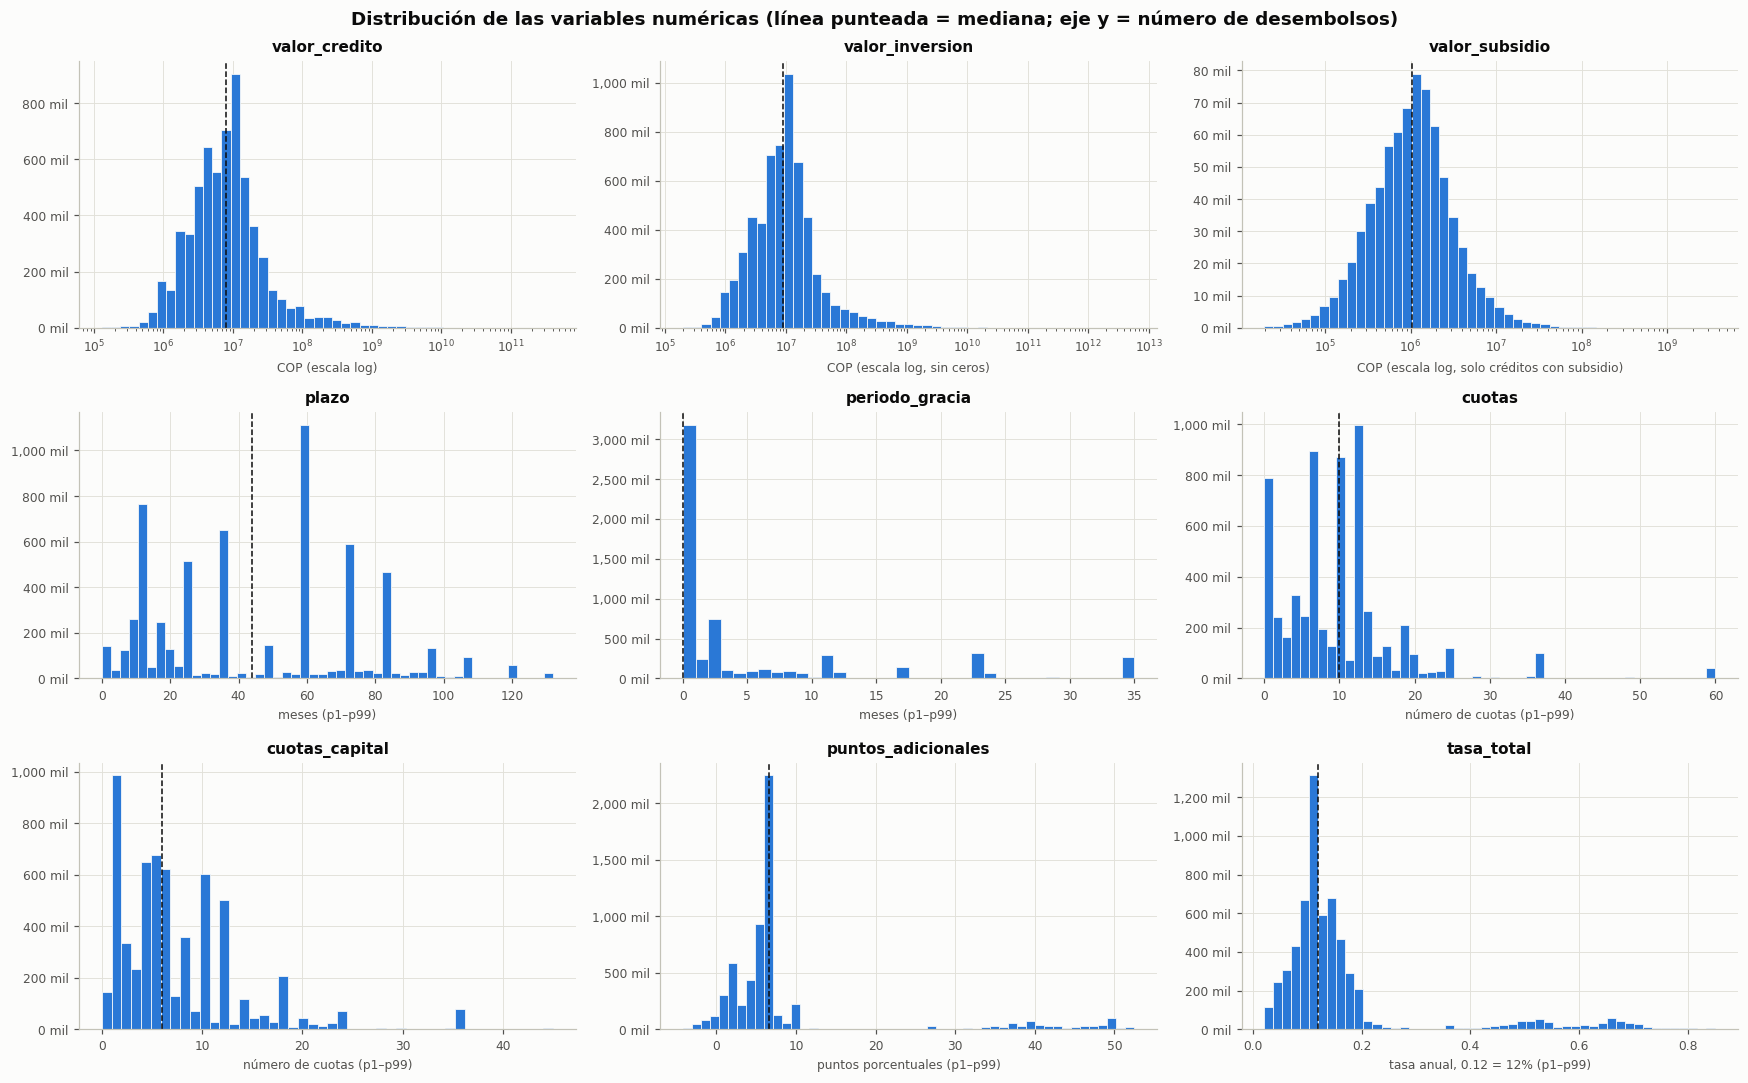

In [9]:
def histograma(ax, s, titulo, log=False, unidad=""):
    s = s.dropna()
    if log:
        s = s[s > 0]  # en escala log solo se grafican (y se resumen) los valores positivos
        s = s[s >= s.quantile(0.001)]  # se omite el 0.1% mas bajo, que estira el eje
        bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 50)
        ax.set_xscale("log")
        mediana = s.median()
    else:
        mediana = s.median()
        s = s[(s >= s.quantile(0.01)) & (s <= s.quantile(0.99))]  # se recortan las colas del 1% para leer el grafico
        bins = min(50, int(s.nunique()))
    ax.hist(s, bins=bins, color=PALETA[0], edgecolor="#fcfcfb", linewidth=0.5)
    ax.axvline(mediana, color="#0b0b0b", linewidth=1, linestyle="--")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(unidad, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:,.0f} mil"))
    ax.tick_params(labelsize=8)


fig, ejes = plt.subplots(3, 3, figsize=(16, 10))
config = {
    "valor_credito": dict(log=True, unidad="COP (escala log)"),
    "valor_inversion": dict(log=True, unidad="COP (escala log, sin ceros)"),
    "valor_subsidio": dict(log=True, unidad="COP (escala log, solo créditos con subsidio)"),
    "plazo": dict(unidad="meses (p1–p99)"),
    "periodo_gracia": dict(unidad="meses (p1–p99)"),
    "cuotas": dict(unidad="número de cuotas (p1–p99)"),
    "cuotas_capital": dict(unidad="número de cuotas (p1–p99)"),
    "puntos_adicionales": dict(unidad="puntos porcentuales (p1–p99)"),
    "tasa_total": dict(unidad="tasa anual, 0.12 = 12% (p1–p99)"),
}
for ax, (col, kw) in zip(ejes.flat, config.items()):
    histograma(ax, fin[col], col, **kw)
fig.suptitle("Distribución de las variables numéricas (línea punteada = mediana; eje y = número de desembolsos)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 1.3 Variables categóricas

Para cada variable categórica se listan sus categorías, con el número de créditos y el porcentaje. Las variables con muchas categorías (municipios, programas, destinos) muestran solo las 15 más frecuentes y agrupan el resto en "Otras". Los vacíos aparecen como "Sin dato".

In [10]:
def es_vacio(v):
    return pd.isna(v) or v == ""


def conteos(s):
    """value_counts con nulos y texto vacio agrupados como 'Sin dato'."""
    vc = s.value_counts(dropna=False)
    idx = ["Sin dato" if es_vacio(i) else i for i in vc.index]
    return vc.groupby(idx, sort=False).sum().sort_values(ascending=False)


def etiquetas(s):
    """Serie con nulos y texto vacio reemplazados por 'Sin dato' (para cruces por año)."""
    s = s.astype("object")
    return s.where(s.notna() & s.ne(""), "Sin dato")


def categorias(col, top=15):
    vc = conteos(fin[col])
    tabla = pd.DataFrame({"créditos": vc, "%": vc / vc.sum() * 100})
    if len(tabla) > top:
        resto = tabla.iloc[top:]
        tabla = pd.concat([tabla.iloc[:top], pd.DataFrame(
            {"créditos": [resto["créditos"].sum()], "%": [resto["%"].sum()]},
            index=[f"Otras ({len(resto)} categorías)"])])
    tabla.index.name = col
    return tabla


CATEGORICAS = [c for c in columnas if TIPO_ANALITICO[c].startswith("Categórica")]
for col in CATEGORICAS:
    print(f"\n{col} — {fin[col].nunique():,} categorías distintas")
    display(categorias(col).style.format({"créditos": "{:,.0f}", "%": "{:.2f}"}))


cod_municipio — 1,116 categorías distintas


,créditos,%
cod_municipio,,
11001,"69,663",1.13
41551,"56,143",0.91
52356,"43,462",0.71
41396,"39,276",0.64
05001,"33,223",0.54
52001,"32,146",0.52
73001,"31,048",0.50
41298,"27,648",0.45
19256,"27,549",0.45



tipo_cartera — 3 categorías distintas


,créditos,%
tipo_cartera,,
Redescuento,"4,733,173",76.85
Sustitutiva,"1,314,303",21.34
Agropecuaria,"111,383",1.81



tipo_intermediario — 4 categorías distintas


...

,créditos,%
ruralidad,,
Intermedio,"2,223,705",36.11
Rural,"1,849,619",30.03
Rural disperso,"1,189,867",19.32
Ciudades y aglomeraciones,"895,471",14.54
Sin dato,197,0.00



Destino — 258 categorías distintas


,créditos,%
Destino,,
Sin dato,"1,235,974",20.07
253400.000000,"672,332",10.92
160000.000000,"420,785",6.83
141100.000000,"320,547",5.20
132310.000000,"304,735",4.95
253100.000000,"291,649",4.74
141430.000000,"238,249",3.87
141150.000000,"191,172",3.10
111500.000000,"146,780",2.38



Nombre_destino — 258 categorías distintas


,créditos,%
Nombre_destino,,
Sin dato,"1,235,974",20.07
Vientres bovinos y bufalinos comerciales cría y D.P,"672,332",10.92
Capital de trabajo Unidad Productiva Campesina,"420,785",6.83
Café,"320,547",5.20
Sostenimiento café,"304,735",4.95
Vientres bovinos comerciales leche,"291,649",4.74
Plátano,"238,249",3.87
Renovación cafetales envejecidos,"191,172",3.10
Papa,"146,780",2.38


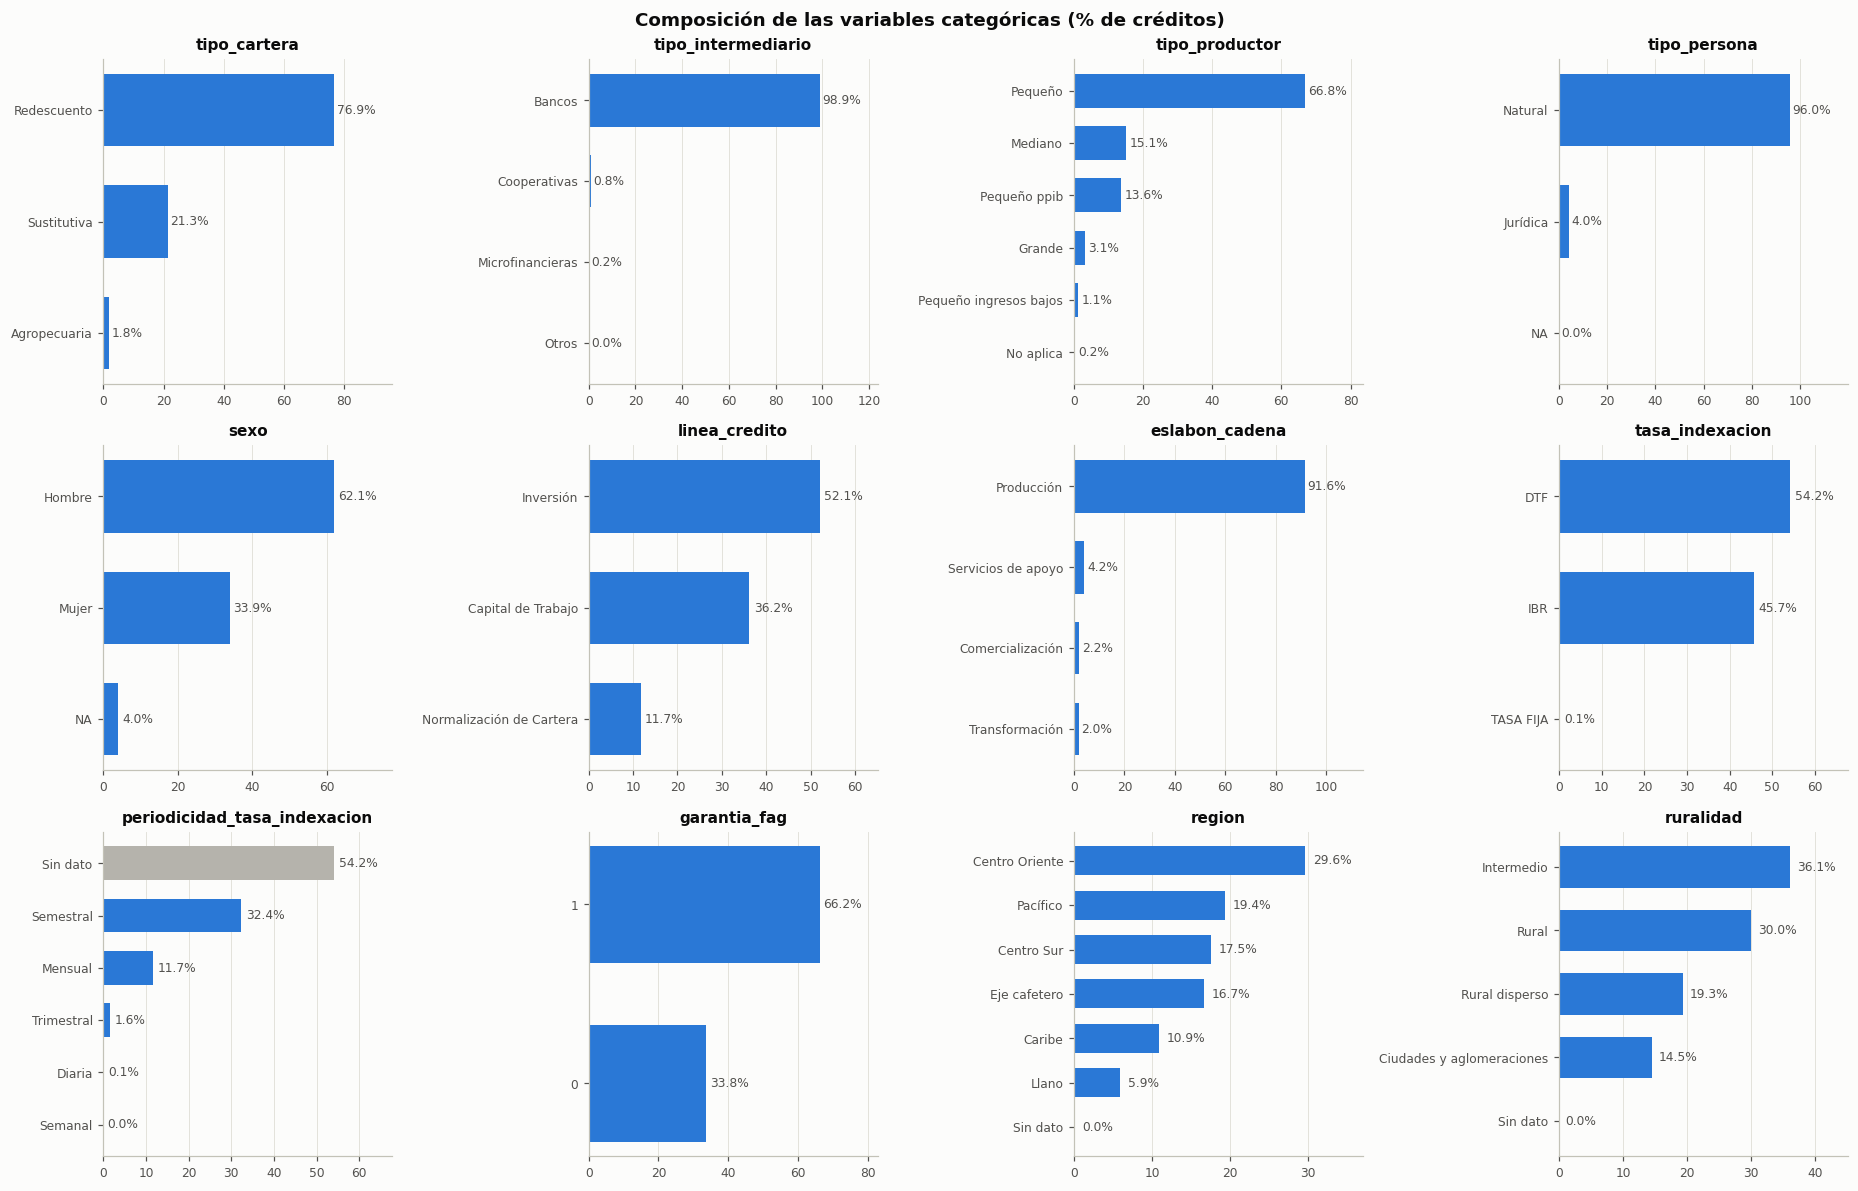

In [11]:
# Graficos de las categoricas con pocas categorias (hasta 8 barras por panel; el resto se agrupa en "Otras")
POCAS = ["tipo_cartera", "tipo_intermediario", "tipo_productor", "tipo_persona", "sexo", "linea_credito",
         "eslabon_cadena", "tasa_indexacion", "periodicidad_tasa_indexacion", "garantia_fag",
         "region", "ruralidad"]
fig, ejes = plt.subplots(3, 4, figsize=(17, 11))
for ax, col in zip(ejes.flat, POCAS):
    vc = conteos(fin[col])
    if len(vc) > 8:
        vc = pd.concat([vc.iloc[:7], pd.Series({"Otras": vc.iloc[7:].sum()})])
    pct = (vc / vc.sum() * 100).iloc[::-1]
    colores = [GRIS_OTROS if str(i) in ("Otras", "Sin dato") else PALETA[0] for i in pct.index]
    ax.barh([str(i)[:28] for i in pct.index], pct.values, color=colores, height=0.65)
    for y, v in enumerate(pct.values):
        ax.text(v + 1, y, f"{v:.1f}%", va="center", fontsize=8, color="#52514e")
    ax.set_xlim(0, pct.max() * 1.25)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", visible=False)
fig.suptitle("Composición de las variables categóricas (% de créditos)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 1.4 Descripción de cada variable

Cada fila de la tabla es un **desembolso**, no un crédito distinto: 10.800 valores de `id_credito` se repiten en 114.464 filas. Son desembolsos sucesivos de una misma obligación, todos de la tarjeta agropecuaria.

**Identificación y fechas**

| Variable | Tipo | Descripción |
|---|---|---|
| `id_credito` | Identificador | Número de la obligación. No es único (ver arriba). |
| `fecha_credito` | Fecha | Fecha del desembolso. Va del 4-ene-2010 al 30-jun-2026, así que **2026 solo tiene seis meses**. |
| `viernes` | Fecha | El viernes de la semana de reporte: siempre cae entre 0 y 6 días antes de `fecha_credito`. Sirve para agregar por semana. |

**Ubicación**

| Variable | Tipo | Descripción |
|---|---|---|
| `cod_municipio` | Categórica (código DANE) | Municipio del crédito, en 5 dígitos. Hay 1.116 municipios. |
| `MPIO` | Categórica (código DANE) | Repite `cod_municipio` (coinciden en el 99,997 % de las filas). |
| `DPNOM`, `DPMP` | Categóricas | Nombre del departamento (32 más Bogotá) y del municipio. Solo 197 filas (0,003 %) vienen vacías, todas con código 27493 (Belén de Bajirá, Chocó, un municipio creado en 2022), entre 2024 y 2026. |
| `region` | Categórica | Seis regiones: Centro Oriente 29,6 %, Pacífico 19,4 %, Centro Sur 17,5 %, Eje cafetero 16,7 %, Caribe 10,9 % y Llano 5,9 %. |
| `ruralidad` | Categórica ordinal | Categoría de ruralidad del DNP del municipio: Ciudades y aglomeraciones 14,5 %, Intermedio 36,1 %, Rural 30,0 % y Rural disperso 19,3 %. |
| `PDET` | Binaria (0/1) | 1 si el municipio es PDET (16,8 % de los desembolsos). |

**Tipo de crédito e intermediario**

| Variable | Tipo | Descripción |
|---|---|---|
| `tipo_cartera` | Categórica | Cómo se fondea el crédito: Redescuento 76,9 %, Sustitutiva 21,3 % y Agropecuaria 1,8 %. |
| `tipo_intermediario` | Categórica | Quién presta: Bancos 98,9 %, Cooperativas 0,8 %, Microfinancieras 0,2 % y Otros (menos del 0,01 %). |
| `linea_credito` | Categórica | Para qué es el crédito: Inversión 52,1 %, Capital de trabajo 36,2 % y Normalización de cartera 11,7 %. |
| `nombre_programa` | Categórica | Programa o producto de FINAGRO. Hay 1.257 y los 15 más frecuentes cubren el 78,7 %. El prefijo "IBR" marca la versión indexada a la IBR de un mismo programa. |
| `garantia_fag` | Binaria (0/1) | 1 si el crédito tiene garantía del Fondo Agropecuario de Garantías (66,2 %). |
| `indicador_lec` | Binaria (0/1) | 1 si el crédito es de una Línea Especial de Crédito, con tasa subsidiada (8,3 %). Aparece desde 2016. |
| `nuevo` | Binaria (0/1) | 29,5 % de las filas tienen 1. Por el nombre parece marcar a un beneficiario nuevo, pero no está documentado: **hay que confirmarlo con el profesor**. |

**Beneficiario**

| Variable | Tipo | Descripción |
|---|---|---|
| `tipo_productor` | Categórica ordinal | Tamaño del productor: Pequeño 66,8 %, Mediano 15,1 %, Pequeño ppib 13,6 % (desde 2023), Grande 3,1 %, Pequeño ingresos bajos 1,1 % (desde 2026) y No aplica 0,2 %. |
| `tipo_beneficiario` | Categórica | 81 etiquetas (dos de ellas son la misma y solo difieren en una tilde: "Victimas" y "Víctimas conflicto armado ppib") que detallan el tipo de productor con poblaciones especiales (desplazados, víctimas, mujer rural, jóvenes, microempresarios). La más frecuente es Pequeño productor, con 53,7 %. |
| `tipo_persona` | Categórica binaria | Natural 96,0 % y Jurídica 4,0 %. Hay 19 filas con "NA". |
| `sexo` | Categórica | Hombre 62,1 %, Mujer 33,9 % y "NA" 4,0 %, que corresponde a las personas jurídicas. |

**Destino y materia prima**

| Variable | Tipo | Descripción |
|---|---|---|
| `cadena` | Categórica | Cadena productiva. Tiene 80 etiquetas, pero corresponden a 61 cadenas: en 2026 FINAGRO cambió el catálogo (nombres con tildes y minúsculas, algunos renombres y cadenas más detalladas; ver 2.5). Las más frecuentes son Café 20,2 %, Ganado doble propósito 14,8 % y Microcrédito 11,2 %. Algunas categorías son **productos financieros y no materias primas**: Microcrédito, Unidad Campesina, Tarjeta Agropecuaria y Actividades Complementarias. |
| `eslabon_cadena` | Categórica | Parte de la cadena que se financia: Producción 91,6 %, Servicios de apoyo 4,2 %, Comercialización 2,2 % y Transformación 2,0 %. |
| `cod_destino` | Categórica (código) | Código del destino específico del crédito. Hay 471 códigos y ninguno viene vacío. |
| `Destino`, `Nombre_destino` | Categóricas | Código y nombre del destino según un catálogo de 258 destinos. Están vacíos en el 20,1 % de las filas, cuando el código no está en el catálogo (por ejemplo, 165000 = microcrédito). Cuando `Destino` existe, es igual a `cod_destino`. |

**Montos y condiciones financieras**

| Variable | Tipo | Descripción |
|---|---|---|
| `valor_credito` | Numérica continua | Monto desembolsado, en pesos nominales. Es muy asimétrica: la mediana es 8 millones, el promedio 51,6 millones y el máximo 405 mil millones. El 1 % de desembolsos más grandes suma el 65 % de todo el dinero. |
| `valor_inversion` | Numérica continua | Valor total del proyecto que se financia. La mediana es 9 millones y el 1,7 % de las filas está en cero. |
| `valor_subsidio` | Numérica continua (texto en BigQuery) | Monto del subsidio asociado al crédito. El 87,9 % está en cero; entre los que tienen subsidio, la mediana es 1,05 millones. |
| `plazo` | Numérica discreta | Plazo en meses. La mediana es 44 y el percentil 99 es 132. |
| `periodo_gracia` | Numérica discreta | Meses de gracia. El 51,7 % no tiene gracia. Hay valores negativos (mínimo −7), que son errores de registro. |
| `cuotas`, `cuotas_capital` | Numéricas discretas | Número total de cuotas y número de cuotas de capital. Las medianas son 10 y 6. |
| `tasa_indexacion` | Categórica | Tasa de referencia: DTF 54,2 %, IBR 45,7 % y tasa fija 0,1 %. Entre 2019 y 2021 se pasó de la DTF a la IBR. |
| `periodicidad_tasa_indexacion` | Categórica | Periodicidad de la IBR (semestral, mensual, trimestral o diaria). Está vacía (54,2 %) en los créditos a DTF. |
| `puntos_adicionales` | Numérica continua | Margen sobre la tasa de referencia, en puntos. La mediana es 6,6. Hay valores negativos y hasta de 100, que son atípicos. |
| `tasa_total` | Numérica continua | Tasa total anual, en fracción (0,12 = 12 %). La mediana es 12 %. Está vacía en el 0,1 % de las filas, que son los créditos a tasa fija. Los valores negativos o mayores al 100 % son atípicos. |

## 2. Distribución de los créditos por año

En esta parte se ve cómo se reparten los desembolsos año a año: cuántos y por cuánto dinero, de qué tipo, en qué lugares y a qué beneficiarios, productores y cadenas productivas.

Algunas notas para leer los resultados:
- **Periodo:** de enero de 2010 a junio de 2026. **2026 solo tiene seis meses**, así que su número de créditos y su monto no se comparan con los de los otros años; sus participaciones (%) sí.
- **Montos nominales** en pesos colombianos (no se ajustan por inflación), en miles de millones de COP (1 billón = 1.000 miles de millones).
- **Ubicación:** se usan las columnas de la propia tabla. Solo 197 filas no traen ubicación, todas del código 27493 (Belén de Bajirá, Chocó, creado en 2022). Como ese municipio tampoco está en la tabla del profesor `Municipios.CODIGO`, se les asigna a mano el departamento (Chocó) y la región (Pacífico); su ruralidad queda como "Sin dato". Los nombres de municipio de la tabla de municipios también salen de `Municipios.CODIGO` (descargada en `datos/profesor/CODIGO.csv`).
- **Colores:** en los gráficos apilados cada categoría conserva su color en los dos paneles. Las categorías poco frecuentes se agrupan en "Otras" (gris) y los vacíos en "Sin dato" (gris claro).

In [12]:
# --- Ubicacion: columnas de la propia tabla; los pocos vacios se completan con Municipios.CODIGO via cod_municipio
municipios = pd.read_csv("datos/profesor/CODIGO.csv", dtype={"cod_dane": str})
geo = (municipios.sort_values("fecha")
       .groupby("cod_dane")[["nombre_departamento", "nombre_municipio", "region", "ruralidad"]]
       .last())  # ultimo valor no nulo de cada municipio
# 27493 = Belén de Bajirá (Chocó), municipio creado en 2022: no esta en Municipios.CODIGO y la tabla lo trae sin ubicacion
geo.loc["27493"] = {"nombre_departamento": "Chocó", "nombre_municipio": "Belén de Bajirá",
                    "region": "Pacífico", "ruralidad": np.nan}
cod = fin["cod_municipio"].astype("object")
for nueva, original, col_geo in [("departamento", "DPNOM", "nombre_departamento"),
                                 ("municipio", "DPMP", "nombre_municipio"),
                                 ("region_c", "region", "region"),
                                 ("ruralidad_c", "ruralidad", "ruralidad")]:
    fin[nueva] = fin[original].astype("object").fillna(cod.map(geo[col_geo])).astype("category")
del cod
print(f"Filas sin departamento: {fin['DPNOM'].isna().sum():,} en la tabla -> "
      f"{fin['departamento'].isna().sum():,} después de completar con Municipios.CODIGO")

# --- Años completos o parciales (meses con desembolsos en cada año)
meses = fin.groupby("anio")["fecha_credito"].agg(desde="min", hasta="max")
meses["meses con datos"] = fin["fecha_credito"].dt.to_period("M").groupby(fin["anio"]).nunique()
ANIOS = list(meses.index)
meses

Filas sin departamento: 197 en la tabla -> 0 después de completar con Municipios.CODIGO


,desde,hasta,meses con datos
anio,,,
2010,2010-01-04,2010-12-30,12
2011,2011-01-03,2011-12-29,12
2012,2012-01-02,2012-12-28,12
2013,2013-01-02,2013-12-30,12
2014,2014-01-02,2014-12-30,12
2015,2015-01-02,2015-12-30,12
2016,2016-01-04,2016-12-29,12
2017,2017-01-02,2017-12-31,12
2018,2018-01-01,2018-12-31,12


In [13]:
# --- Funciones para cruzar una variable con el año
MMM = 1e9  # miles de millones de COP


def agrupar_top(s, top):
    """Deja las `top` categorias con mas creditos; el resto pasa a 'Otras'. Devuelve (serie, orden)."""
    s = etiquetas(s)
    tops = [c for c in s.value_counts().index if c != "Sin dato"][:top]
    return s.where(s.isin(tops) | s.eq("Sin dato"), "Otras"), tops


def por_anio(col, top=7):
    """Tablas categoria x año: numero de creditos y monto (miles de millones COP)."""
    s, tops = agrupar_top(fin[col], top)
    n = pd.crosstab(s, fin["anio"])
    monto = fin["valor_credito"].groupby([s, fin["anio"]]).sum().unstack(fill_value=0) / MMM
    orden = tops + [c for c in ["Otras", "Sin dato"] if c in n.index]
    return n.reindex(orden).fillna(0), monto.reindex(orden).fillna(0)


def participacion(pv):
    return pv.div(pv.sum(axis=0), axis=1) * 100


def apiladas(ax, pv, titulo, ylabel="% del año"):
    """Barras apiladas al 100% por año. El color sigue a la categoria (mismo orden en todos los paneles)."""
    datos = participacion(pv)
    x = [str(a) for a in datos.columns]
    base, i = np.zeros(len(x)), 0
    for cat, fila in datos.iterrows():
        if cat == "Otras":
            color = GRIS_OTROS
        elif cat == "Sin dato":
            color = "#dcdad3"
        else:
            color, i = PALETA[i], i + 1
        ax.bar(x, fila.values, bottom=base, color=color, label=str(cat)[:45], width=0.72,
               edgecolor="#fcfcfb", linewidth=1.5)
        base += fila.values
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100)
    ax.grid(axis="x", visible=False)


def figura_por_anio(col, titulo, top=7):
    """Dos paneles (participacion en creditos y en monto) + tablas de apoyo."""
    n, monto = por_anio(col, top)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    apiladas(a1, n, "Participación en el número de créditos")
    apiladas(a2, monto, "Participación en el monto desembolsado", ylabel="")
    h, l = a1.get_legend_handles_labels()
    fig.legend(h[::-1], l[::-1], loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
    fig.suptitle(titulo, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()
    print("Número de créditos (miles)")
    display((n / 1e3).style.format("{:,.1f}"))
    print("Participación en el número de créditos (%)")
    display(participacion(n).style.format("{:.1f}"))
    print("Monto desembolsado (miles de millones de COP)")
    display(monto.style.format("{:,.0f}"))
    return n, monto


CMAP_AZUL = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "azul", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def mapa_calor(ax, pv, titulo, fmt="{:,.0f}", ancho=32):
    im = ax.imshow(pv.values, cmap=CMAP_AZUL, aspect="auto")
    ax.set_xticks(range(pv.shape[1]), [str(c) for c in pv.columns])
    ax.set_yticks(range(pv.shape[0]), [str(i)[:ancho] for i in pv.index])
    ax.tick_params(labelsize=8)
    ax.grid(False)
    tope = np.nanmax(pv.values)
    for (r, c), v in np.ndenumerate(pv.values):
        ax.text(c, r, fmt.format(v), ha="center", va="center", fontsize=7,
                color="#ffffff" if v > 0.55 * tope else "#0b0b0b")
    ax.set_title(titulo, fontsize=11)
    return im

### 2.1 Cuántos créditos y cuánto dinero por año

,créditos,monto (miles de millones COP),crédito mediano (millones COP),crédito promedio (millones COP),% con garantía FAG,municipios con créditos,meses con datos
anio,,,,,,,
2010,"249,151","4,182",5.0,16.8,85.6,"1,070",12
2011,"274,944","5,473",6.0,19.9,76.8,"1,089",12
2012,"267,357","6,471",6.5,24.2,83.1,"1,088",12
2013,"278,025","6,961",7.0,25.0,88.1,"1,092",12
2014,"245,005","8,113",7.5,33.1,86.3,"1,090",12
2015,"226,905","8,487",8.0,37.4,85.7,"1,093",12
2016,"310,974","10,385",7.0,33.4,60.3,"1,097",12
2017,"445,437","14,775",6.0,33.2,54.9,"1,098",12
2018,"414,982","15,264",6.0,36.8,57.9,"1,094",12


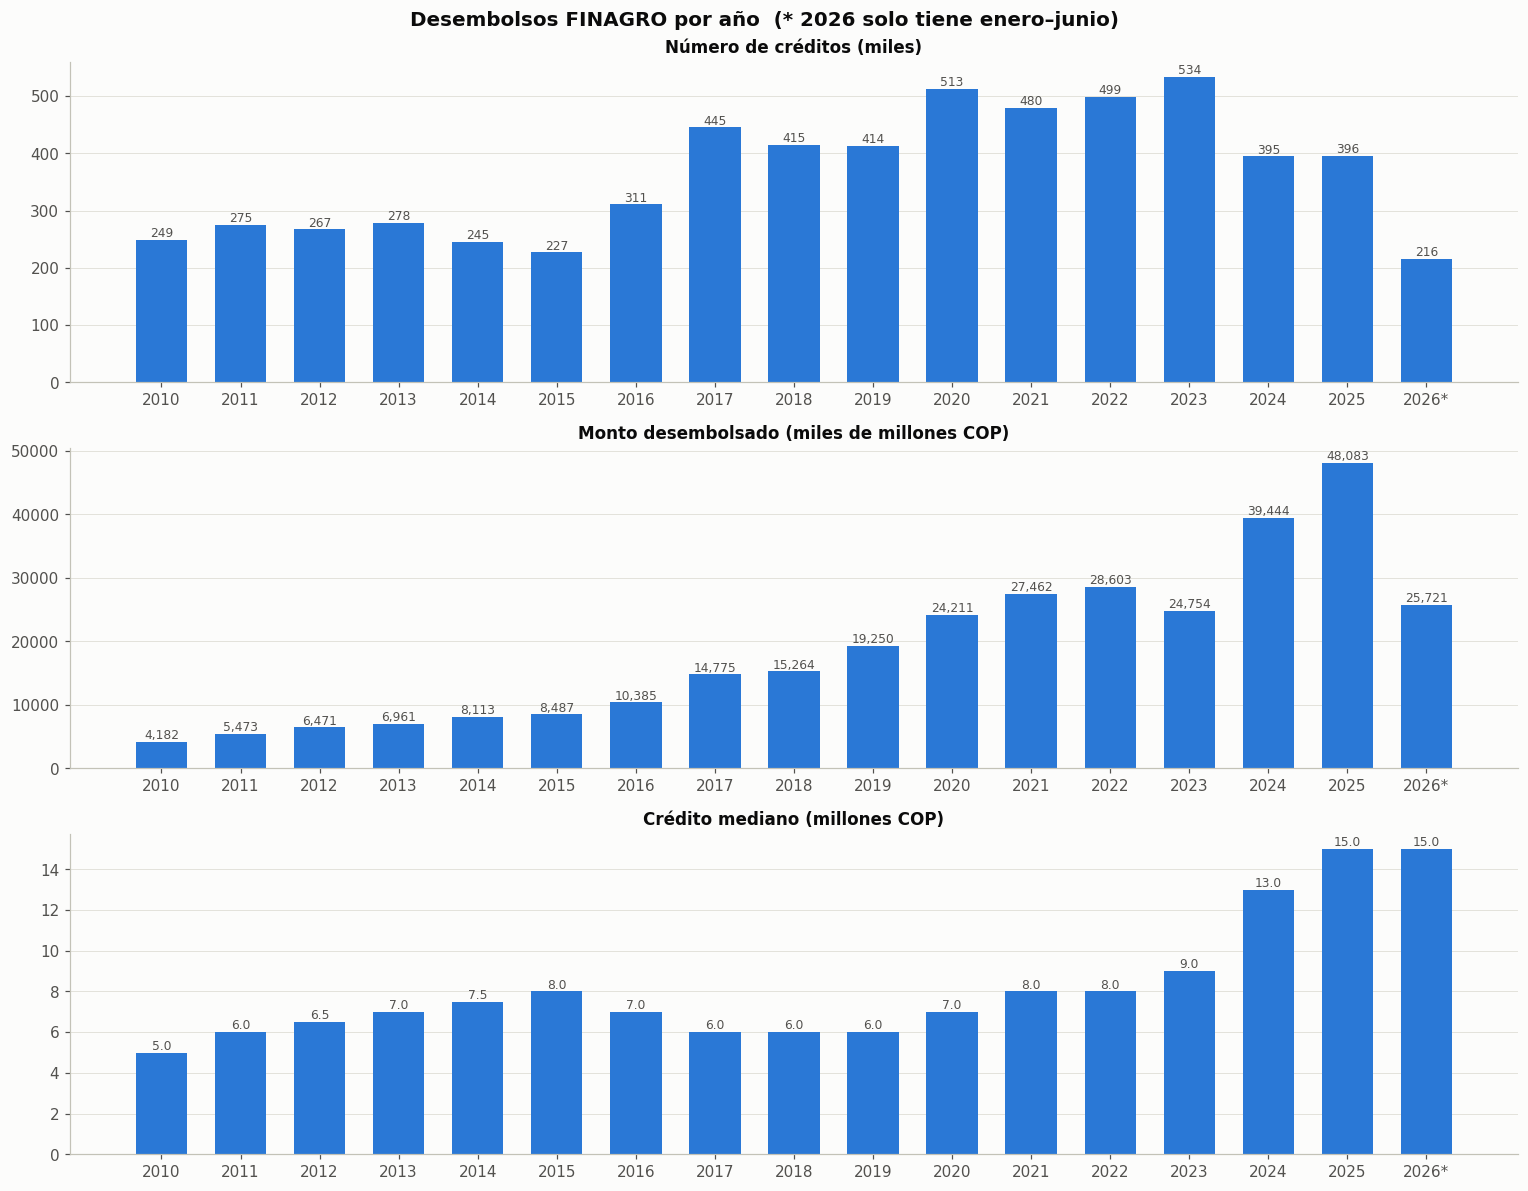

In [14]:
g = fin.groupby("anio")
totales = pd.DataFrame({
    "créditos": g.size(),
    "monto (miles de millones COP)": g["valor_credito"].sum() / MMM,
    "crédito mediano (millones COP)": g["valor_credito"].median() / 1e6,
    "crédito promedio (millones COP)": g["valor_credito"].mean() / 1e6,
    "% con garantía FAG": g["garantia_fag"].mean() * 100,
    "municipios con créditos": g["cod_municipio"].nunique(),
    "meses con datos": meses["meses con datos"],
})
display(totales.style.format({"créditos": "{:,.0f}", "monto (miles de millones COP)": "{:,.0f}",
                              "crédito mediano (millones COP)": "{:,.1f}",
                              "crédito promedio (millones COP)": "{:,.1f}",
                              "% con garantía FAG": "{:.1f}", "municipios con créditos": "{:,.0f}"}))

# Tres paneles con su propio eje (no se mezclan escalas en un mismo eje)
fig, ejes = plt.subplots(3, 1, figsize=(14, 11))
x = [f"{a}*" if m < 12 else str(a) for a, m in meses["meses con datos"].items()]
series = [(totales["créditos"] / 1e3, "Número de créditos (miles)", "{:,.0f}"),
          (totales["monto (miles de millones COP)"], "Monto desembolsado (miles de millones COP)", "{:,.0f}"),
          (totales["crédito mediano (millones COP)"], "Crédito mediano (millones COP)", "{:,.1f}")]
for ax, (s, titulo, fmt) in zip(ejes, series):
    ax.bar(x, s.values, color=PALETA[0], width=0.65)
    for xi, v in zip(x, s.values):
        ax.text(xi, v, fmt.format(v), ha="center", va="bottom", fontsize=8, color="#52514e")
    ax.set_title(titulo, fontsize=11)
    ax.grid(axis="x", visible=False)
fig.suptitle("Desembolsos FINAGRO por año  (* 2026 solo tiene enero–junio)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

**Lectura:**
- **Número de desembolsos:** pasó de unos 250 mil al año (2010–2015) a unos 500 mil (2020–2023). En 2024 y 2025 bajó a unos 395 mil.
- **Monto:** creció mucho más que el número, de 4,2 billones de pesos en 2010 a 48,1 billones en 2025. En los primeros seis meses de 2026 ya van 25,7 billones. Son montos nominales, así que una parte del crecimiento es inflación.
- **Tamaño del crédito típico:** como el número bajó y el monto subió, cada crédito es más grande. La mediana pasó de 5 millones (2010) a 15 millones (2025–2026) y el promedio de 17 a unos 120 millones. El promedio es muy superior a la mediana porque unos pocos créditos muy grandes pesan mucho.
- **Cobertura:** es casi nacional. Cada año hay desembolsos en unos 1.100 municipios.

### 2.2 Qué tipos de crédito se otorgan

Se describen con tres variables:
- **`linea_credito`:** para qué se usa el crédito (inversión, capital de trabajo o normalización de cartera).
- **`tipo_cartera`:** de dónde salen los recursos. En *redescuento* FINAGRO fondea al banco. *Sustitutiva* y *agropecuaria* son cartera que el banco presta con recursos propios y que registra ante FINAGRO.
- **`nombre_programa`:** el programa o producto específico de FINAGRO.

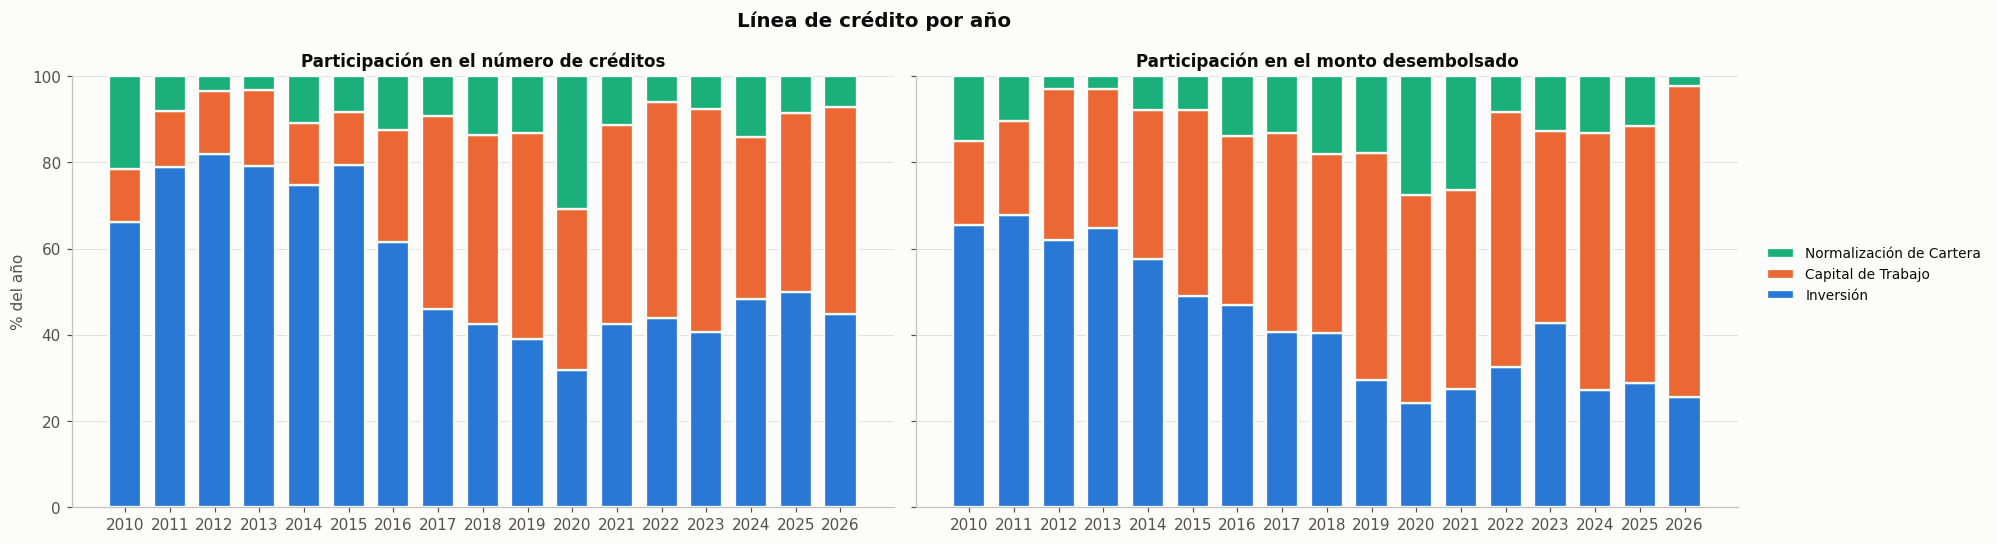

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
linea_credito,,,,,,,,,,,,,,,,,
Inversión,165.1,216.9,219.4,220.0,183.4,180.0,191.4,204.4,176.4,161.5,162.9,204.1,219.5,217.0,190.6,197.9,96.6
Capital de Trabajo,30.6,35.5,38.7,49.2,34.8,28.0,80.8,199.7,182.2,197.6,192.2,221.2,249.9,276.1,148.1,163.7,103.7
Normalización de Cartera,53.4,22.5,9.2,8.8,26.8,18.8,38.8,41.4,56.3,54.6,158.2,54.7,29.8,40.4,56.2,34.0,15.6


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
linea_credito,,,,,,,,,,,,,,,,,
Inversión,66.3,78.9,82.1,79.1,74.9,79.3,61.6,45.9,42.5,39.0,31.7,42.5,44.0,40.7,48.3,50.0,44.8
Capital de Trabajo,12.3,12.9,14.5,17.7,14.2,12.4,26.0,44.8,43.9,47.8,37.4,46.1,50.1,51.8,37.5,41.4,48.0
Normalización de Cartera,21.4,8.2,3.5,3.2,10.9,8.3,12.5,9.3,13.6,13.2,30.8,11.4,6.0,7.6,14.2,8.6,7.2


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
linea_credito,,,,,,,,,,,,,,,,,
Inversión,"2,743","3,707","4,010","4,514","4,670","4,156","4,864","5,997","6,175","5,702","5,874","7,548","9,317","10,575","10,756","13,918","6,566"
Capital de Trabajo,810,"1,194","2,267","2,237","2,807","3,658","4,070","6,821","6,335","10,118","11,666","12,638","16,891","11,009","23,475","28,593","18,563"
Normalización de Cartera,629,572,194,210,636,672,"1,451","1,957","2,755","3,430","6,671","7,275","2,396","3,171","5,212","5,572",591


In [15]:
_ = figura_por_anio("linea_credito", "Línea de crédito por año")

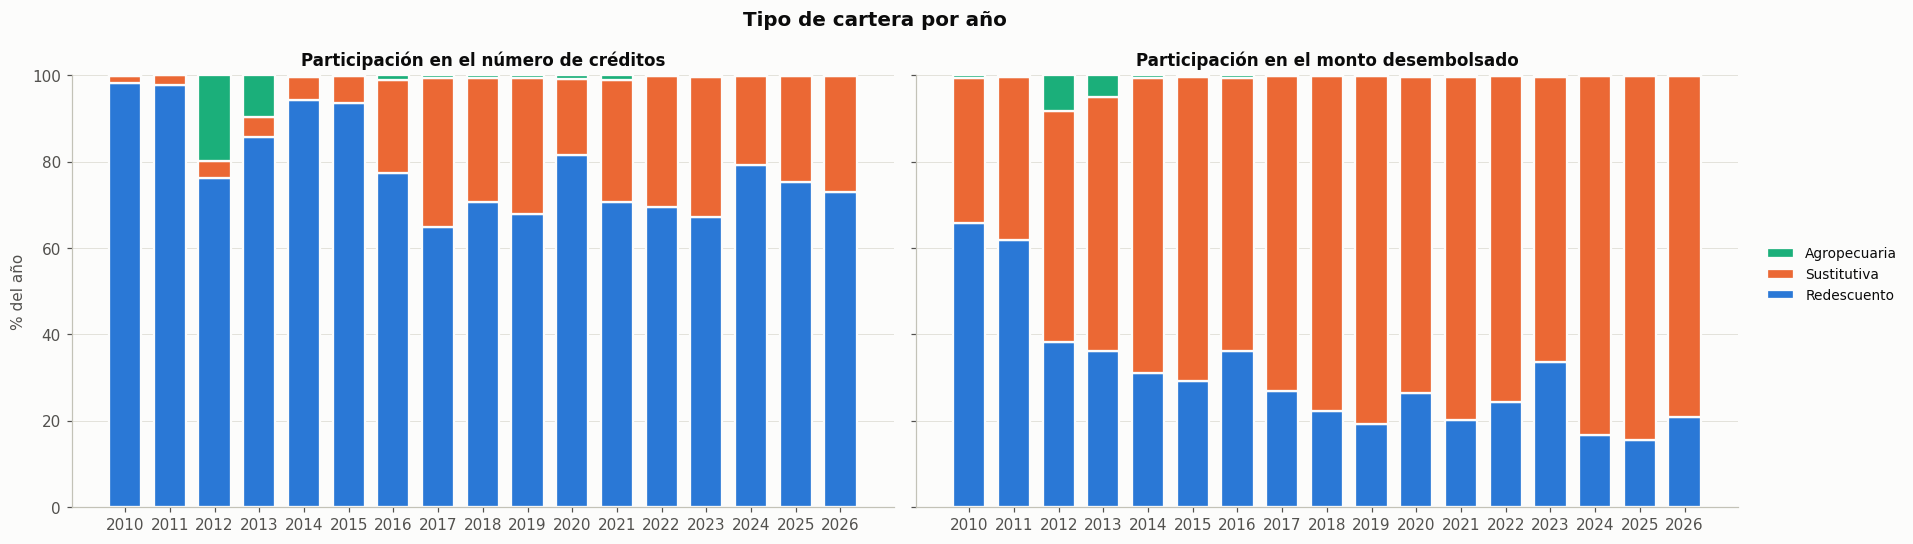

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_cartera,,,,,,,,,,,,,,,,,
Redescuento,244.9,268.8,203.8,238.5,231.0,212.2,240.4,289.3,293.1,281.2,419.0,339.1,346.4,357.9,312.5,297.5,157.6
Sustitutiva,4.0,5.9,10.5,12.3,13.2,14.1,67.0,153.1,119.0,130.2,89.4,135.2,151.6,173.0,81.3,97.0,57.6
Agropecuaria,0.2,0.2,53.1,27.2,0.9,0.5,3.6,3.0,2.9,2.3,4.9,5.6,1.2,2.7,1.2,1.2,0.6


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_cartera,,,,,,,,,,,,,,,,,
Redescuento,98.3,97.8,76.2,85.8,94.3,93.5,77.3,64.9,70.6,68.0,81.6,70.7,69.4,67.1,79.1,75.2,73.0
Sustitutiva,1.6,2.2,3.9,4.4,5.4,6.2,21.5,34.4,28.7,31.5,17.4,28.2,30.4,32.4,20.6,24.5,26.7
Agropecuaria,0.1,0.1,19.9,9.8,0.4,0.2,1.2,0.7,0.7,0.6,1.0,1.2,0.2,0.5,0.3,0.3,0.3


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_cartera,,,,,,,,,,,,,,,,,
Redescuento,"2,750","3,382","2,474","2,517","2,529","2,480","3,758","3,979","3,394","3,691","6,402","5,567","6,989","8,347","6,617","7,470","5,383"
Sustitutiva,"1,407","2,062","3,468","4,097","5,529","5,965","6,569","10,762","11,832","15,514","17,698","21,792","21,543","16,310","32,747","40,572","20,316"
Agropecuaria,25,29,529,347,55,42,58,35,38,44,111,103,71,97,79,41,23


In [16]:
_ = figura_por_anio("tipo_cartera", "Tipo de cartera por año")

Los 15 programas cubren 78.7% de los créditos (1257 programas en total)


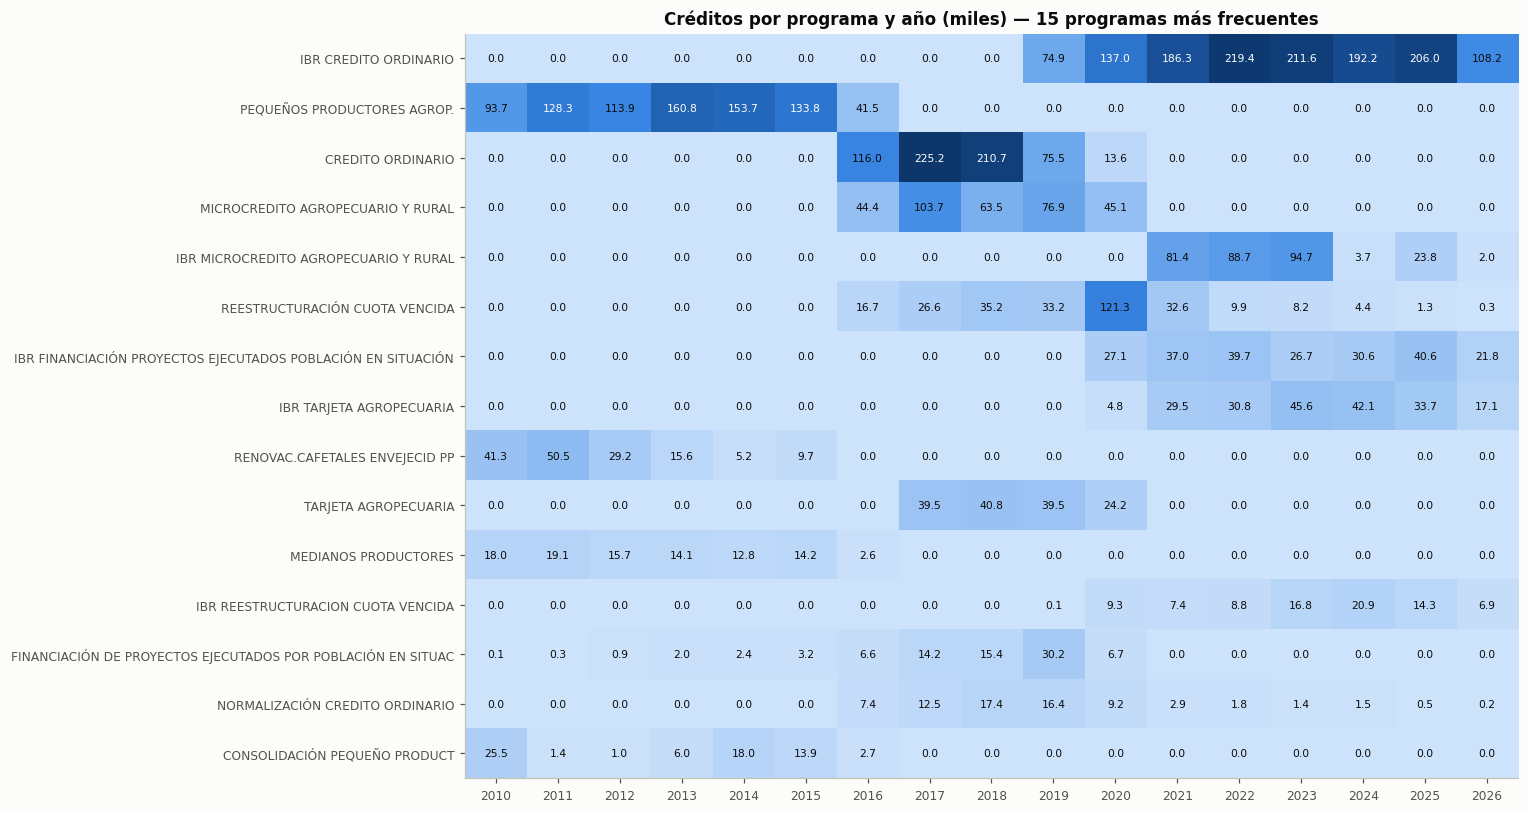

In [17]:
# Programas: hay demasiados para un grafico apilado; mapa de calor de los 15 con mas creditos en todo el periodo
s, tops = agrupar_top(fin["nombre_programa"], 15)
prog_n = pd.crosstab(s, fin["anio"]).reindex(tops)
print(f"Los 15 programas cubren {prog_n.values.sum() / len(fin):.1%} de los créditos "
      f"({fin['nombre_programa'].nunique()} programas en total)")
fig, ax = plt.subplots(figsize=(14, 7.5))
mapa_calor(ax, prog_n / 1e3, "Créditos por programa y año (miles) — 15 programas más frecuentes",
           fmt="{:,.1f}", ancho=60)
fig.tight_layout()
plt.show()

**Lectura:**
- **Línea de crédito:** hasta 2015 la mayoría de los desembolsos eran de inversión (entre 66 % y 82 %). Desde 2017 el capital de trabajo es casi la mitad de los desembolsos, y en monto pasó del 19 % (2010) al 72 % (2026). La normalización de cartera tuvo un pico en 2020: 31 % de los desembolsos, el año de las medidas de alivio por el COVID-19.
- **Tipo de cartera:** el redescuento es la mayoría de los desembolsos (entre 65 % y 98 %), pero la cartera sustitutiva concentra la mayor parte del dinero (cerca del 80 % desde 2018). Es decir, los créditos grandes los hacen los bancos con recursos propios.
- **Programa:** hay 1.257 nombres de programa y 15 cubren el 79 % de los desembolsos, pero los nombres cambian por periodos. Entre 2010 y 2016 dominan "Pequeños productores agrop." y "Medianos productores". Entre 2016 y 2020 dominan "Crédito ordinario" y "Microcrédito agropecuario y rural". Desde 2019 aparecen sus versiones "IBR", por el cambio de tasa de referencia de la DTF a la IBR. El pico de "Reestructuración cuota vencida" en 2020 (121 mil desembolsos) coincide con los alivios por el COVID-19. Para comparar programas en el tiempo hay que agruparlos por tipo y no por nombre.

### 2.3 Dónde se reparten los créditos

Se miran cuatro niveles: región, departamento, municipio y el tipo de municipio (categoría de ruralidad del DNP y si es PDET).

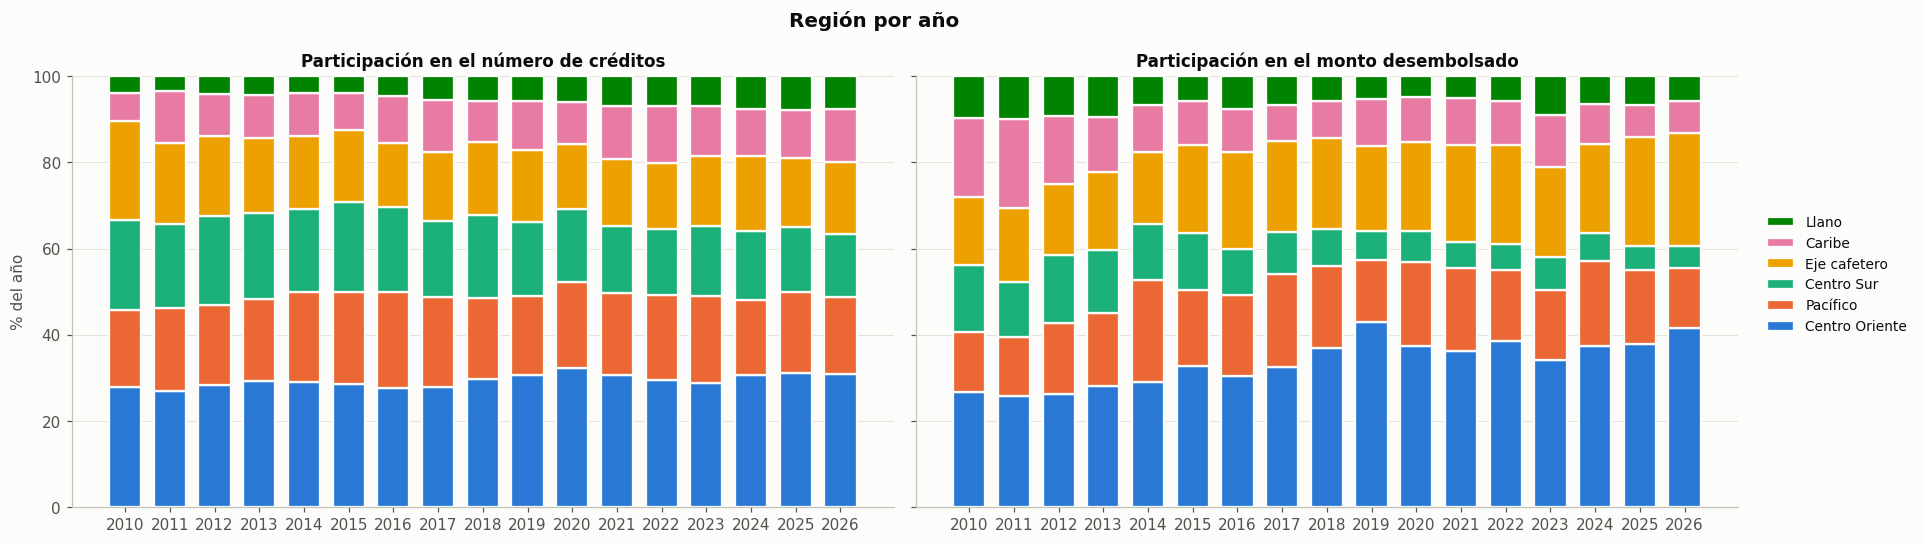

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
region_c,,,,,,,,,,,,,,,,,
Centro Oriente,69.7,74.2,76.0,81.2,71.3,65.2,86.2,124.2,123.5,127.3,166.1,147.0,146.9,154.4,121.2,123.7,66.6
Pacífico,44.1,53.2,49.3,52.8,51.1,48.0,69.4,92.9,78.2,75.0,102.6,91.6,98.5,107.1,69.2,73.8,38.8
Centro Sur,52.0,53.4,55.1,55.6,46.9,47.5,60.9,78.4,79.5,71.3,86.1,74.7,76.7,87.0,62.9,59.8,31.3
Eje cafetero,57.6,51.5,50.0,48.3,41.5,37.8,46.3,71.3,70.7,69.2,78.2,74.4,76.4,85.9,68.2,63.2,36.4
Caribe,16.2,33.2,25.9,28.0,24.4,19.5,33.5,54.0,38.7,47.0,49.1,59.0,65.7,62.8,43.4,43.9,26.3
Llano,9.6,9.4,11.1,12.2,9.7,9.0,14.6,24.6,24.3,23.8,31.1,33.3,35.0,36.4,30.1,31.2,16.4


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
region_c,,,,,,,,,,,,,,,,,
Centro Oriente,28.0,27.0,28.4,29.2,29.1,28.7,27.7,27.9,29.8,30.8,32.4,30.6,29.4,28.9,30.7,31.3,30.9
Pacífico,17.7,19.3,18.4,19.0,20.9,21.2,22.3,20.9,18.8,18.1,20.0,19.1,19.7,20.1,17.5,18.6,18.0
Centro Sur,20.9,19.4,20.6,20.0,19.2,20.9,19.6,17.6,19.2,17.2,16.8,15.6,15.4,16.3,15.9,15.1,14.5
Eje cafetero,23.1,18.7,18.7,17.4,16.9,16.6,14.9,16.0,17.0,16.7,15.2,15.5,15.3,16.1,17.3,16.0,16.9
Caribe,6.5,12.1,9.7,10.1,10.0,8.6,10.8,12.1,9.3,11.4,9.6,12.3,13.2,11.8,11.0,11.1,12.2
Llano,3.8,3.4,4.1,4.4,4.0,3.9,4.7,5.5,5.9,5.8,6.1,6.9,7.0,6.8,7.6,7.9,7.6


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
region_c,,,,,,,,,,,,,,,,,
Centro Oriente,"1,122","1,408","1,703","1,951","2,357","2,775","3,158","4,820","5,645","8,295","9,086","9,932","11,054","8,441","14,746","18,223","10,697"
Pacífico,578,754,"1,066","1,187","1,927","1,494","1,946","3,166","2,897","2,748","4,687","5,281","4,689","4,010","7,789","8,199","3,576"
Centro Sur,646,695,"1,021","1,013","1,044","1,124","1,114","1,440","1,311","1,285","1,727","1,657","1,720","1,937","2,535","2,687","1,307"
Eje cafetero,659,941,"1,060","1,257","1,358","1,734","2,331","3,113","3,234","3,825","5,011","6,197","6,548","5,136","8,172","12,148","6,735"
Caribe,771,"1,126","1,030",895,887,874,"1,048","1,237","1,288","2,062","2,535","3,023","2,968","2,985","3,624","3,589","1,900"
Llano,406,549,592,658,540,486,788,999,889,"1,034","1,165","1,372","1,624","2,245","2,577","3,237","1,505"


In [18]:
_ = figura_por_anio("region_c", "Región por año")

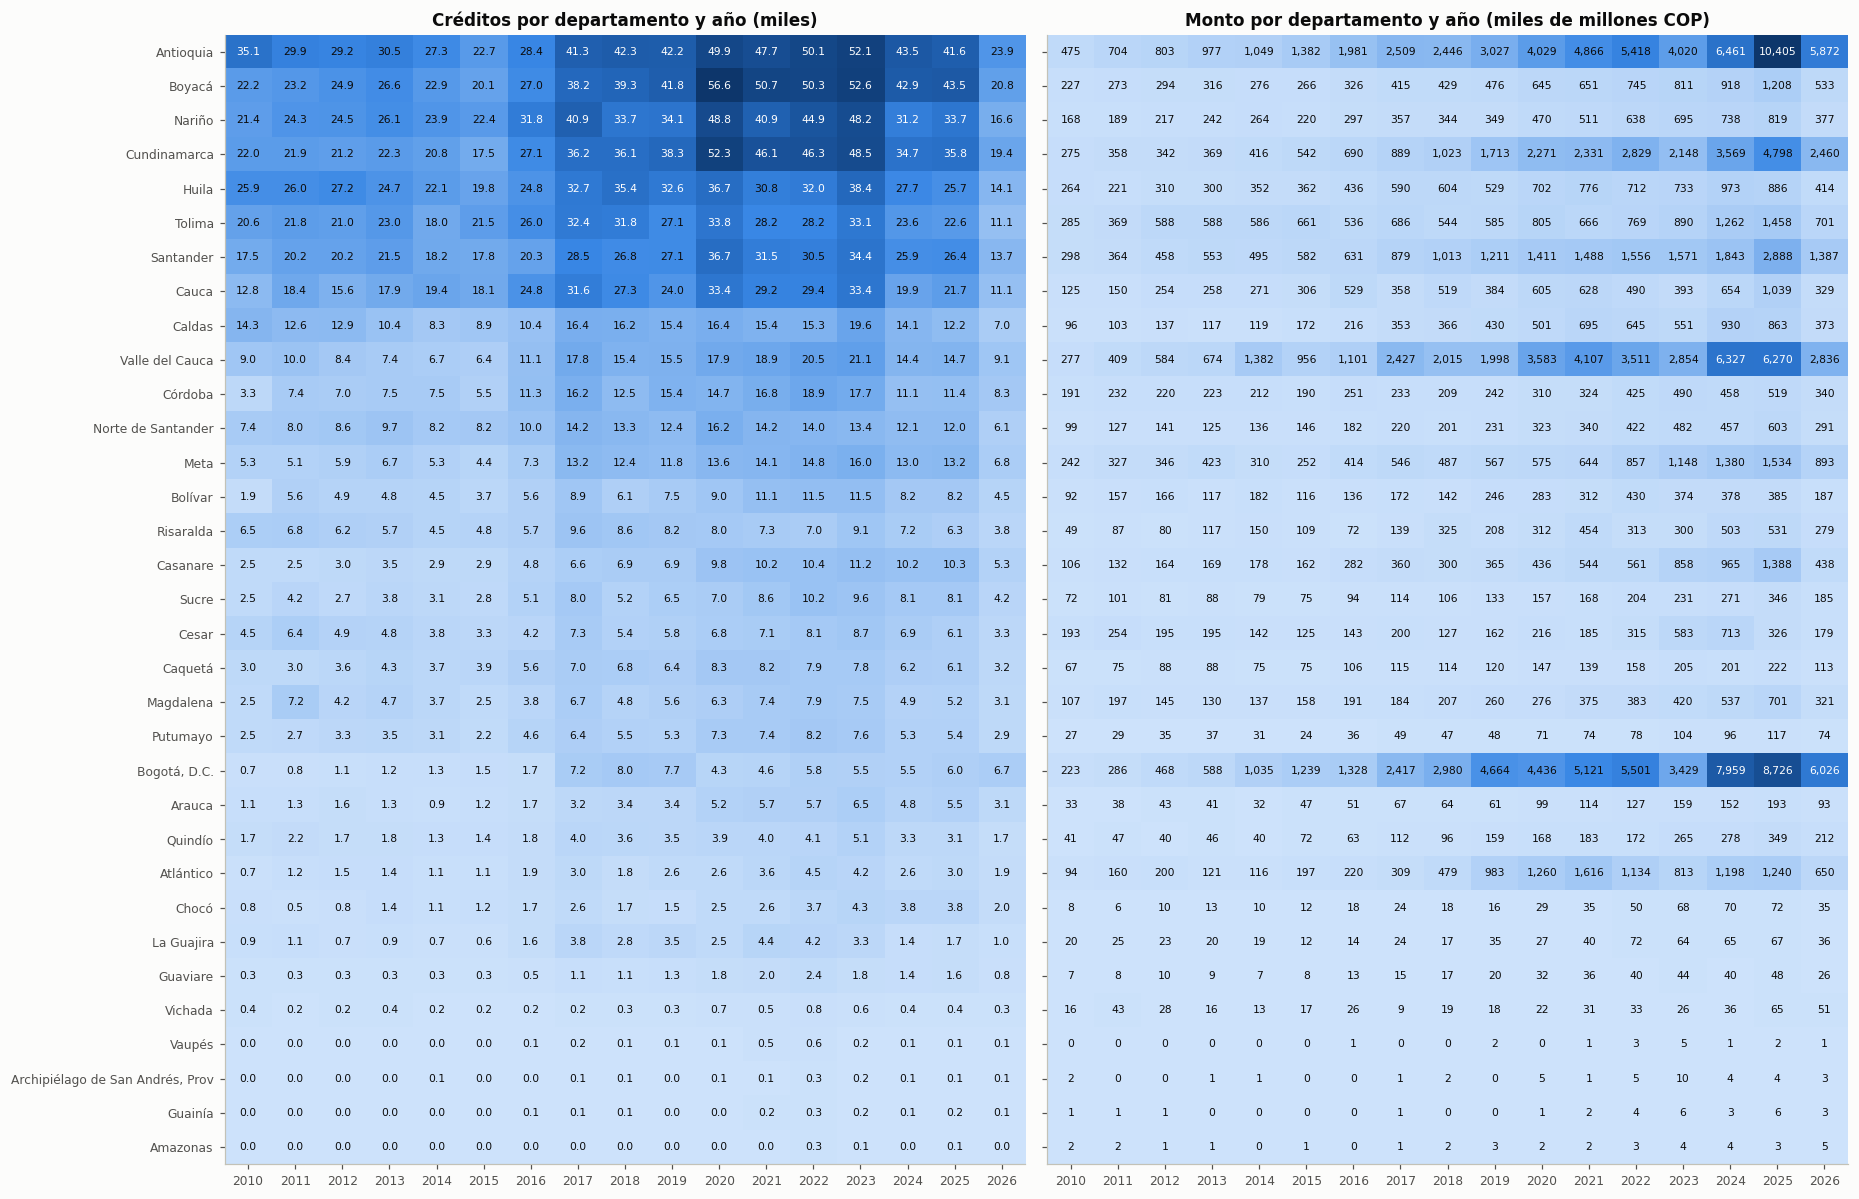

,créditos,% créditos,monto (miles de millones COP),% monto,crédito mediano (millones COP)
departamento,,,,,
Antioquia,"637,631",10.4,"56,424",17.8,7.3
Boyacá,"603,506",9.8,"8,810",2.8,9.1
Nariño,"547,273",8.9,"6,898",2.2,7.0
Cundinamarca,"546,571",8.9,"27,023",8.5,8.0
Huila,"476,291",7.7,"9,164",2.9,6.0
Tolima,"423,906",6.9,"11,979",3.8,7.5
Santander,"416,984",6.8,"18,627",5.9,9.0
Cauca,"387,907",6.3,"7,293",2.3,6.0
Caldas,"225,914",3.7,"6,667",2.1,4.5


In [19]:
# Departamentos: todos, ordenados por numero total de creditos. Dos mapas de calor con su propia escala.
depto = etiquetas(fin["departamento"])
dep_n = pd.crosstab(depto, fin["anio"])
dep_m = fin["valor_credito"].groupby([depto, fin["anio"]]).sum().unstack(fill_value=0) / MMM
orden = dep_n.sum(axis=1).sort_values(ascending=False).index
dep_n, dep_m = dep_n.loc[orden], dep_m.loc[orden]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 11))
mapa_calor(a1, dep_n / 1e3, "Créditos por departamento y año (miles)", fmt="{:,.1f}")
mapa_calor(a2, dep_m, "Monto por departamento y año (miles de millones COP)", fmt="{:,.0f}")
a2.tick_params(labelleft=False)
fig.tight_layout()
plt.show()

part_dep = pd.DataFrame({
    "créditos": dep_n.sum(axis=1),
    "% créditos": dep_n.sum(axis=1) / dep_n.values.sum() * 100,
    "monto (miles de millones COP)": dep_m.sum(axis=1),
    "% monto": dep_m.sum(axis=1) / dep_m.values.sum() * 100,
    "crédito mediano (millones COP)": fin["valor_credito"].groupby(depto).median().reindex(orden) / 1e6,
})
part_dep.style.format({"créditos": "{:,.0f}", "% créditos": "{:.1f}", "monto (miles de millones COP)": "{:,.0f}",
                       "% monto": "{:.1f}", "crédito mediano (millones COP)": "{:,.1f}"})

In [20]:
# Municipios: los 20 con mas creditos y que tan concentrado esta el credito entre municipios
mun = fin.groupby("cod_municipio", observed=True).agg(creditos=("valor_credito", "size"),
                                                      monto=("valor_credito", "sum"))
mun["monto"] /= MMM
mun.insert(0, "municipio", [f"{geo['nombre_municipio'].get(c, '?')} ({geo['nombre_departamento'].get(c, '?')})"
                            for c in mun.index])
mun = mun.sort_values("creditos", ascending=False)
mun["% créditos"] = mun["creditos"] / mun["creditos"].sum() * 100
mun["% monto"] = mun["monto"] / mun["monto"].sum() * 100
display(mun.head(20).rename(columns={"creditos": "créditos", "monto": "monto (miles de millones COP)"})
        .style.format({"créditos": "{:,.0f}", "monto (miles de millones COP)": "{:,.0f}",
                       "% créditos": "{:.2f}", "% monto": "{:.2f}"}))

# Concentracion: que % de los creditos (y del monto) se llevan el 1%, 10% y 50% de municipios con mas creditos (o monto)
n_mun = len(mun)
pct_n = mun["% créditos"].sort_values(ascending=False).cumsum().values
pct_m = mun["% monto"].sort_values(ascending=False).cumsum().values
conc = pd.DataFrame({f"{p}% de municipios ({int(np.ceil(n_mun * p / 100))})":
                     {"% de créditos": pct_n[int(np.ceil(n_mun * p / 100)) - 1],
                      "% del monto": pct_m[int(np.ceil(n_mun * p / 100)) - 1]}
                     for p in (1, 10, 50)}).T
print(f"{n_mun:,} códigos de municipio con al menos un crédito en el periodo")
conc.style.format("{:.1f}")

,municipio,créditos,monto (miles de millones COP),% créditos,% monto
cod_municipio,,,,,
11001,"Bogotá, D.C. (Bogotá, D.C.)","69,663","56,426",1.13,17.76
41551,Pitalito (Huila),"56,143",663,0.91,0.21
52356,Ipiales (Nariño),"43,462",685,0.71,0.22
41396,La Plata (Huila),"39,276",306,0.64,0.10
05001,Medellín (Antioquia),"33,223","23,564",0.54,7.42
52001,Pasto (Nariño),"32,146","1,093",0.52,0.34
73001,Ibagué (Tolima),"31,048","4,070",0.50,1.28
41298,Garzón (Huila),"27,648",452,0.45,0.14
19256,El Tambo (Cauca),"27,549",202,0.45,0.06


1,116 códigos de municipio con al menos un crédito en el periodo


,% de créditos,% del monto
1% de municipios (12),7.2,44.6
10% de municipios (112),32.7,73.2
50% de municipios (558),81.5,93.8


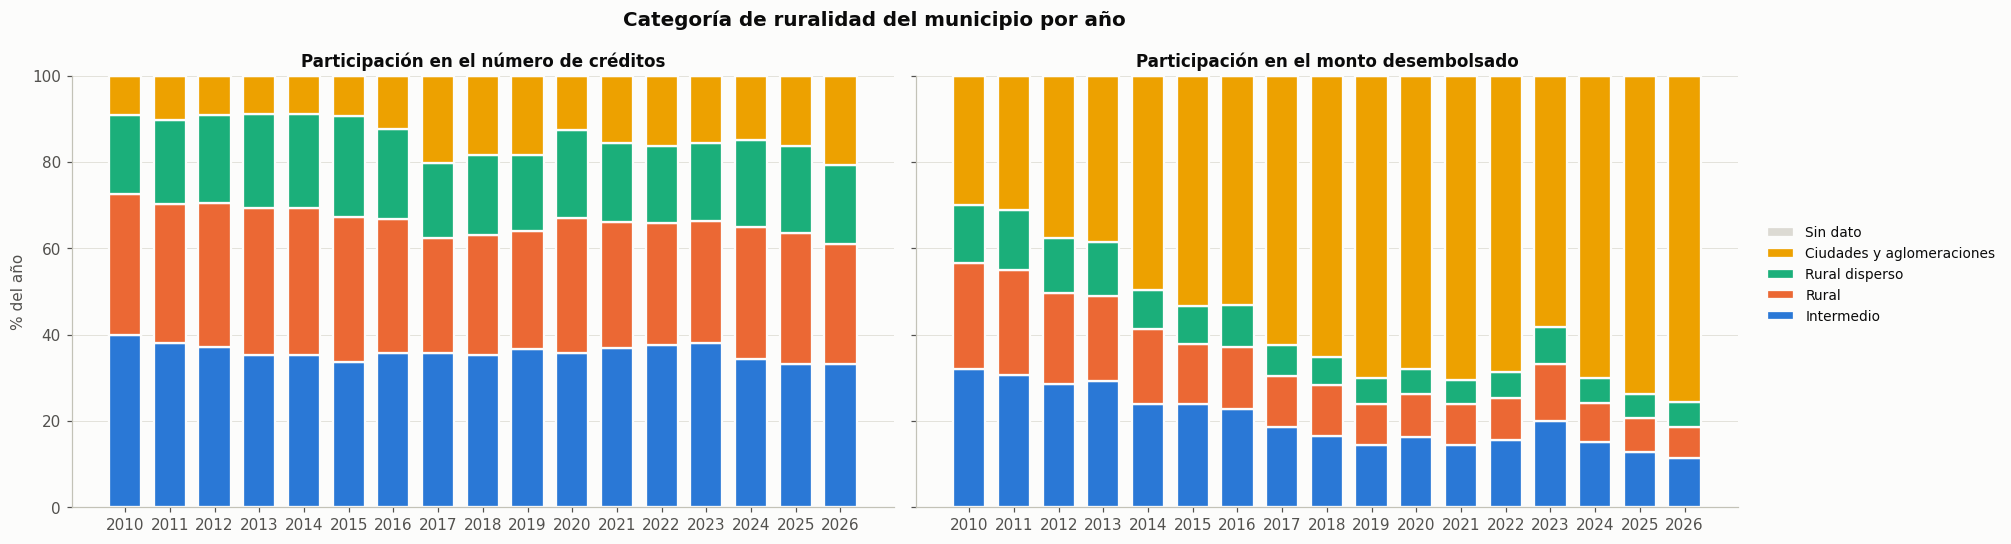

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ruralidad_c,,,,,,,,,,,,,,,,,
Intermedio,99.6,104.6,99.1,98.1,86.6,76.6,111.4,159.7,146.3,151.4,183.9,177.0,188.1,202.6,135.9,131.4,71.4
Rural,81.4,88.3,89.2,94.7,83.5,75.9,96.4,118.5,115.1,113.8,160.5,139.9,140.9,151.0,120.7,119.7,60.3
Rural disperso,45.7,53.7,54.9,60.6,53.0,52.9,64.6,77.3,77.2,72.7,104.1,88.5,89.0,96.5,79.8,79.8,39.6
Ciudades y aglomeraciones,22.5,28.3,24.2,24.6,21.9,21.4,38.6,89.9,76.4,75.8,64.8,74.7,81.2,83.5,58.6,64.7,44.4
Sin dato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ruralidad_c,,,,,,,,,,,,,,,,,
Intermedio,40.0,38.0,37.1,35.3,35.3,33.8,35.8,35.9,35.2,36.6,35.8,36.9,37.7,38.0,34.4,33.2,33.1
Rural,32.7,32.1,33.4,34.1,34.1,33.5,31.0,26.6,27.7,27.5,31.3,29.1,28.2,28.3,30.6,30.2,27.9
Rural disperso,18.3,19.5,20.5,21.8,21.7,23.3,20.8,17.4,18.6,17.6,20.3,18.4,17.8,18.1,20.2,20.2,18.3
Ciudades y aglomeraciones,9.0,10.3,9.0,8.9,8.9,9.4,12.4,20.2,18.4,18.3,12.6,15.6,16.3,15.6,14.8,16.3,20.6
Sin dato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
ruralidad_c,,,,,,,,,,,,,,,,,
Intermedio,"1,335","1,676","1,842","2,034","1,951","2,029","2,356","2,735","2,514","2,764","3,936","3,987","4,463","4,951","5,929","6,161","2,940"
Rural,"1,032","1,335","1,364","1,367","1,403","1,179","1,508","1,745","1,806","1,854","2,406","2,580","2,810","3,291","3,581","3,780","1,869"
Rural disperso,565,757,827,881,731,744,992,"1,077",991,"1,155","1,437","1,529","1,694","2,107","2,265","2,654","1,480"
Ciudades y aglomeraciones,"1,249","1,705","2,438","2,680","4,029","4,534","5,528","9,219","9,953","13,476","16,431","19,366","19,637","14,405","27,668","35,484","19,430"
Sin dato,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2


In [21]:
_ = figura_por_anio("ruralidad_c", "Categoría de ruralidad del municipio por año")

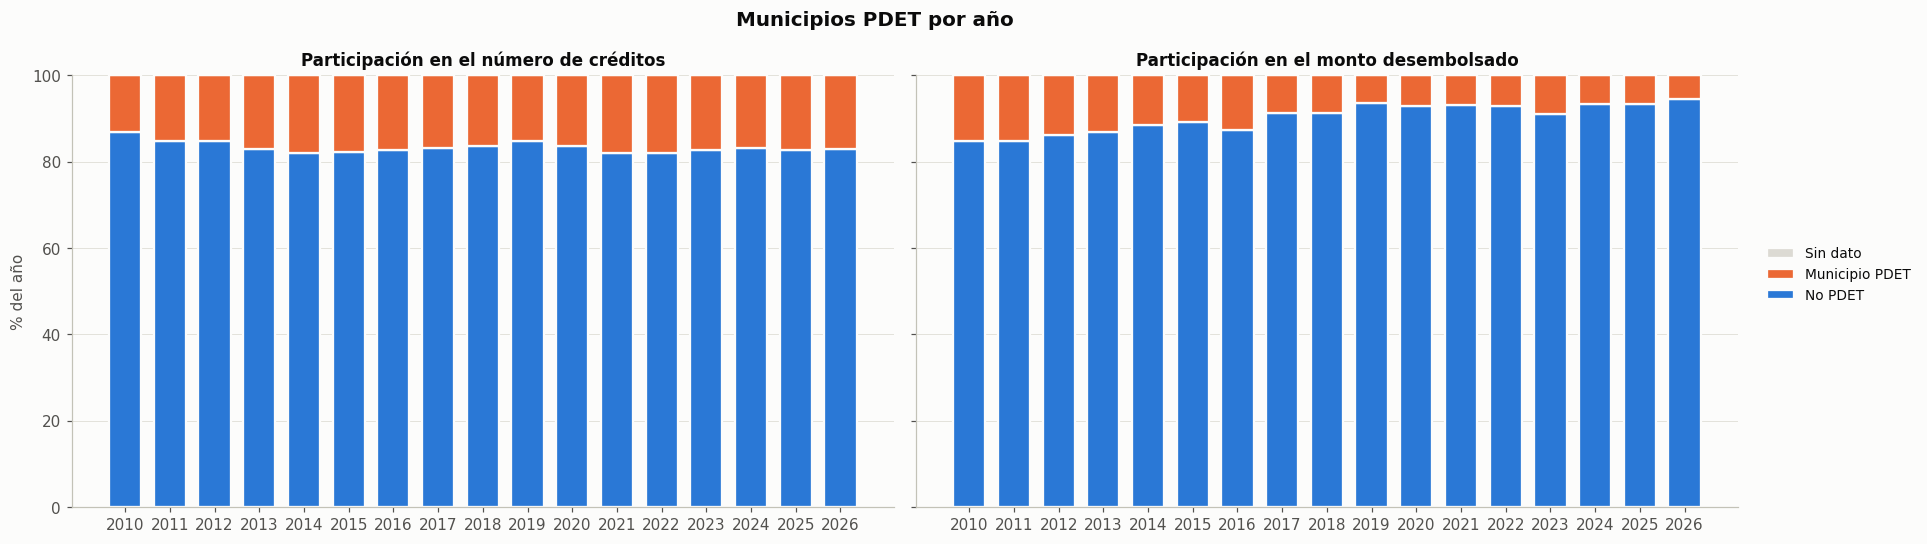

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
PDET_txt,,,,,,,,,,,,,,,,,
No PDET,216.4,233.4,226.4,230.6,201.0,186.6,256.8,370.5,346.8,350.3,428.9,393.5,408.8,441.3,328.7,326.9,179.2
Municipio PDET,32.8,41.6,41.0,47.5,44.0,40.3,54.2,74.9,68.2,63.5,84.3,86.5,90.4,92.3,66.2,68.6,36.6
Sin dato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
PDET_txt,,,,,,,,,,,,,,,,,
No PDET,86.8,84.9,84.7,82.9,82.1,82.3,82.6,83.2,83.6,84.7,83.6,82.0,81.9,82.7,83.2,82.6,83.0
Municipio PDET,13.2,15.1,15.3,17.1,17.9,17.7,17.4,16.8,16.4,15.3,16.4,18.0,18.1,17.3,16.8,17.3,16.9
Sin dato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
PDET_txt,,,,,,,,,,,,,,,,,
No PDET,"3,545","4,643","5,582","6,045","7,182","7,567","9,074","13,467","13,916","18,009","22,470","25,547","26,555","22,517","36,836","44,839","24,298"
Municipio PDET,637,830,889,916,931,920,"1,311","1,309","1,348","1,241","1,741","1,915","2,049","2,237","2,607","3,240","1,420"
Sin dato,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2


In [22]:
# PDET: la columna PDET viene vacia donde tampoco hay departamento; se reporta tal cual
fin["PDET_txt"] = fin["PDET"].map({1: "Municipio PDET", 0: "No PDET"}).astype("category")
_ = figura_por_anio("PDET_txt", "Municipios PDET por año")

**Lectura:**
- **Regiones:** su peso en el número de desembolsos es bastante estable. Centro Oriente tiene cerca del 30 % de los desembolsos y ganó participación en el monto (del 27 % en 2010 al 42 % en 2026). Centro Sur perdió peso: del 21 % al 15 % de los desembolsos y del 15 % al 5 % del monto.
- **Departamentos:** Antioquia, Boyacá, Nariño, Cundinamarca y Huila reúnen cerca del 46 % de los desembolsos. En monto, en cambio, lideran Antioquia (17,8 %), **Bogotá (17,8 % del monto con solo el 1,1 % de los desembolsos, con una mediana de 40 millones)** y Valle del Cauca (13 %).
- **Concentración:** es mucho mayor en el dinero que en el número. El 1 % de los municipios (12) recibe el 7 % de los desembolsos, pero el 45 % del monto. El 10 % de los municipios recibe el 33 % de los desembolsos y el 73 % del monto. Los montos altos de Bogotá, Medellín o Cali corresponden a empresas grandes registradas ahí. **Ojo:** el municipio del crédito no siempre es el lugar donde está la finca o el cultivo, algo importante al cruzar estos datos con deforestación.
- **Ruralidad:** cerca del 85 % de los desembolsos va a municipios intermedios, rurales o rurales dispersos. El monto, sin embargo, se concentra cada vez más en ciudades y aglomeraciones: del 30 % en 2010 al 75 % en 2026.
- **PDET:** los municipios PDET reciben cerca del 17 % de los desembolsos todos los años, pero su participación en el monto cayó del 15 % (2010) al 5,5 % (2026).

### 2.4 Quiénes reciben los créditos

- **`tipo_productor`:** tamaño del productor según FINAGRO (pequeño, mediano, grande, etc.).
- **`tipo_beneficiario`:** una versión más detallada, que incluye poblaciones especiales como víctimas, desplazados, mujer rural y jóvenes.
- **`tipo_persona`:** persona natural o jurídica.
- **`sexo`:** solo tiene sentido para personas naturales; en las jurídicas viene como "NA".

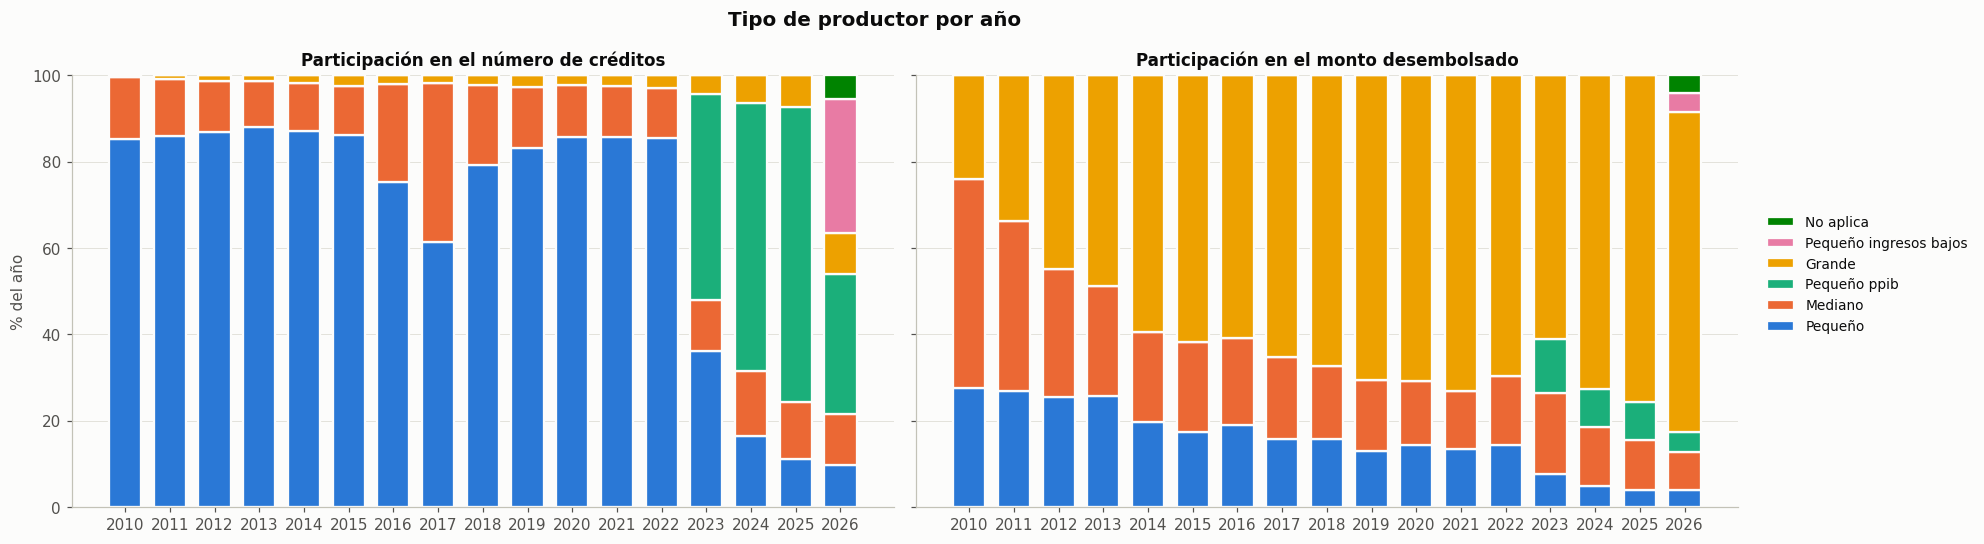

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_productor,,,,,,,,,,,,,,,,,
Pequeño,212.5,236.4,232.3,244.8,213.3,195.3,234.2,273.1,328.4,343.8,439.7,411.3,426.9,193.5,65.1,44.1,21.2
Mediano,35.6,35.9,31.6,29.2,27.2,26.0,70.5,164.2,76.7,58.8,61.7,56.9,57.8,62.7,59.5,52.6,25.4
Pequeño ppib,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,254.5,244.7,269.8,70.0
Grande,1.0,2.6,3.5,4.0,4.5,5.6,6.2,8.2,9.8,11.1,11.8,11.8,14.6,22.9,25.7,29.2,20.1
Pequeño ingresos bajos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.3
No aplica,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.8


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_productor,,,,,,,,,,,,,,,,,
Pequeño,85.3,86.0,86.9,88.1,87.1,86.1,75.3,61.3,79.1,83.1,85.7,85.7,85.5,36.3,16.5,11.1,9.8
Mediano,14.3,13.1,11.8,10.5,11.1,11.5,22.7,36.9,18.5,14.2,12.0,11.9,11.6,11.8,15.1,13.3,11.8
Pequeño ppib,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.7,62.0,68.2,32.4
Grande,0.4,0.9,1.3,1.4,1.8,2.5,2.0,1.8,2.4,2.7,2.3,2.4,2.9,4.3,6.5,7.4,9.3
Pequeño ingresos bajos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.2
No aplica,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.4


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_productor,,,,,,,,,,,,,,,,,
Pequeño,"1,156","1,478","1,646","1,792","1,605","1,488","1,988","2,349","2,408","2,504","3,514","3,695","4,148","1,899","1,986","1,941","1,046"
Mediano,"2,021","2,153","1,922","1,767","1,684","1,759","2,083","2,806","2,579","3,147","3,581","3,668","4,524","4,623","5,301","5,538","2,217"
Pequeño ppib,0,0,0,0,0,0,0,0,0,0,0,0,0,"3,113","3,467","4,237","1,215"
Grande,"1,005","1,842","2,903","3,402","4,824","5,240","6,314","9,620","10,277","13,599","17,116","20,098","19,931","15,119","28,689","36,366","19,028"
Pequeño ingresos bajos,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"1,153"
No aplica,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"1,063"


In [23]:
_ = figura_por_anio("tipo_productor", "Tipo de productor por año")

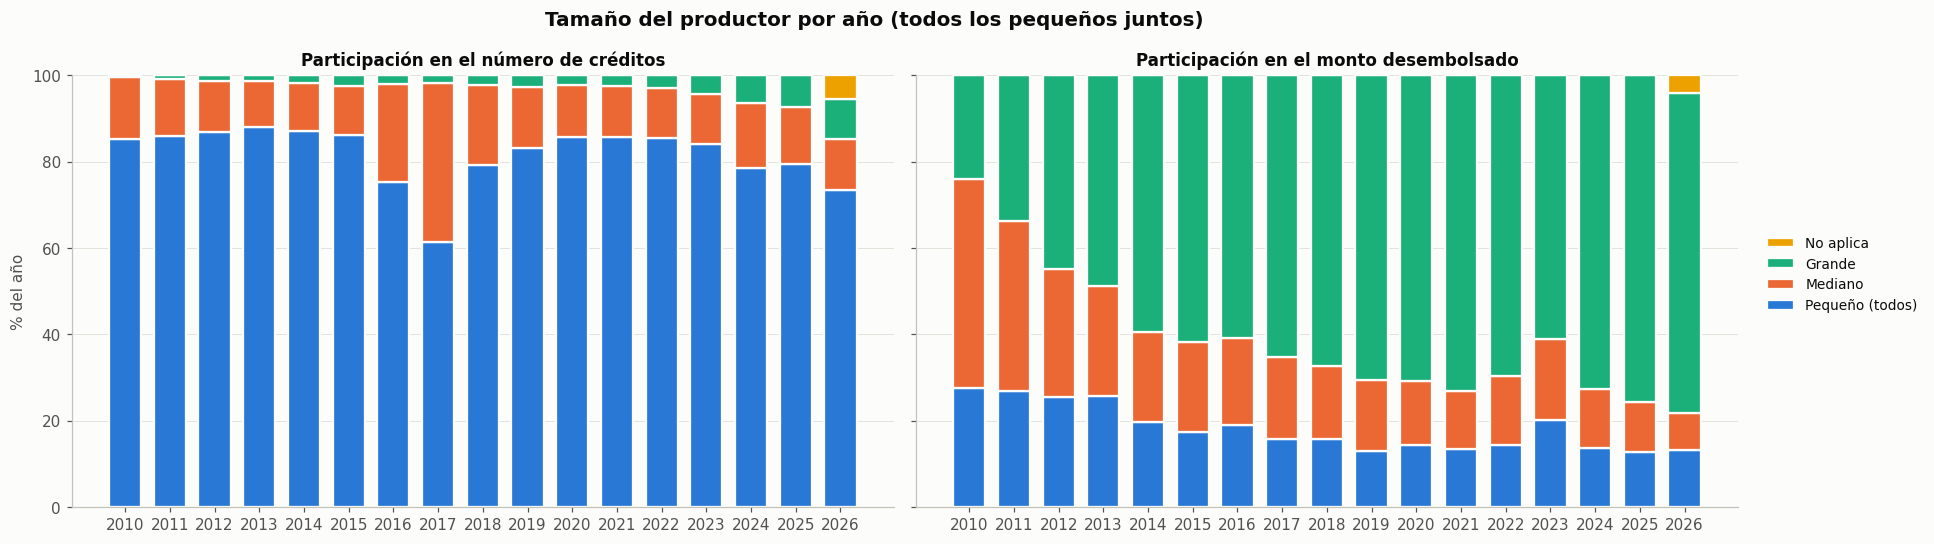

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
productor_agrupado,,,,,,,,,,,,,,,,,
Pequeño (todos),212.5,236.4,232.3,244.8,213.3,195.3,234.2,273.1,328.4,343.8,439.7,411.3,426.9,448.0,309.8,313.9,158.5
Mediano,35.6,35.9,31.6,29.2,27.2,26.0,70.5,164.2,76.7,58.8,61.7,56.9,57.8,62.7,59.5,52.6,25.4
Grande,1.0,2.6,3.5,4.0,4.5,5.6,6.2,8.2,9.8,11.1,11.8,11.8,14.6,22.9,25.7,29.2,20.1
No aplica,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.8


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
productor_agrupado,,,,,,,,,,,,,,,,,
Pequeño (todos),85.3,86.0,86.9,88.1,87.1,86.1,75.3,61.3,79.1,83.1,85.7,85.7,85.5,84.0,78.4,79.3,73.4
Mediano,14.3,13.1,11.8,10.5,11.1,11.5,22.7,36.9,18.5,14.2,12.0,11.9,11.6,11.8,15.1,13.3,11.8
Grande,0.4,0.9,1.3,1.4,1.8,2.5,2.0,1.8,2.4,2.7,2.3,2.4,2.9,4.3,6.5,7.4,9.3
No aplica,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.4


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
productor_agrupado,,,,,,,,,,,,,,,,,
Pequeño (todos),"1,156","1,478","1,646","1,792","1,605","1,488","1,988","2,349","2,408","2,504","3,514","3,695","4,148","5,013","5,453","6,178","3,413"
Mediano,"2,021","2,153","1,922","1,767","1,684","1,759","2,083","2,806","2,579","3,147","3,581","3,668","4,524","4,623","5,301","5,538","2,217"
Grande,"1,005","1,842","2,903","3,402","4,824","5,240","6,314","9,620","10,277","13,599","17,116","20,098","19,931","15,119","28,689","36,366","19,028"
No aplica,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"1,063"


In [24]:
# En 2023 FINAGRO empezo a separar a los pequenos productores de ingresos bajos ("Pequeño ppib") y en 2026 aparece
# "Pequeño ingresos bajos": son cambios de clasificacion. Para ver la tendencia se agrupan todos los pequenos.
fin["productor_agrupado"] = (fin["tipo_productor"].astype("object")
                             .replace({"Pequeño": "Pequeño (todos)", "Pequeño ppib": "Pequeño (todos)",
                                       "Pequeño ingresos bajos": "Pequeño (todos)"})
                             .astype("category"))
_ = figura_por_anio("productor_agrupado", "Tamaño del productor por año (todos los pequeños juntos)")

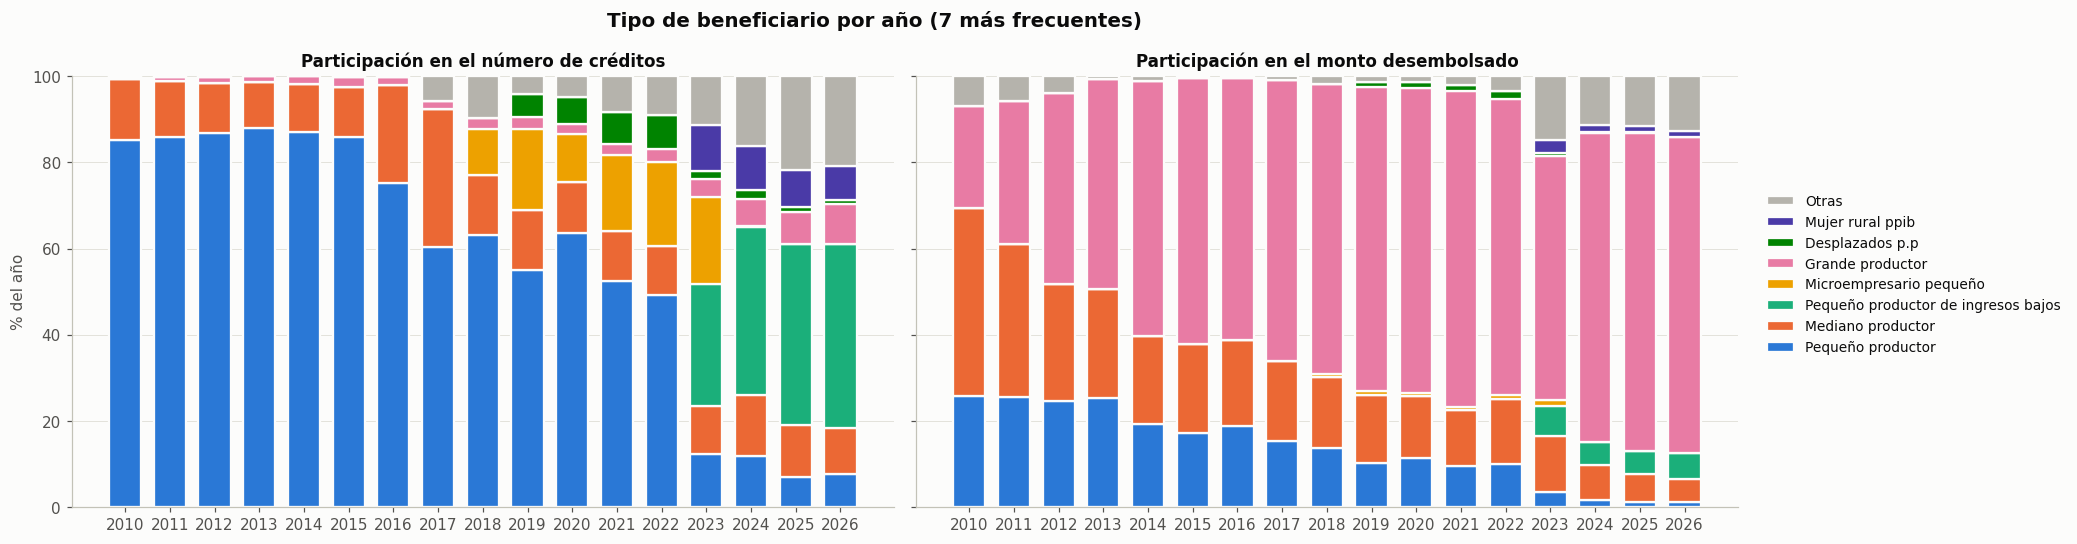

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_beneficiario,,,,,,,,,,,,,,,,,
Pequeño productor,212.3,236.2,232.1,244.7,213.2,195.0,234.0,269.2,262.5,227.9,326.7,252.1,246.1,66.1,47.0,28.0,16.4
Mediano productor,35.4,35.5,31.2,29.2,27.2,26.0,70.5,142.5,56.9,57.7,60.1,55.4,56.6,59.6,55.9,47.4,23.5
Pequeño productor de ingresos bajos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.2,153.9,166.5,92.0
Microempresario pequeño,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.1,77.5,57.3,84.8,97.4,107.4,0.5,0.0,0.0
Grande productor,1.0,2.5,3.5,3.9,4.5,5.6,6.2,8.2,9.8,11.1,11.7,11.7,14.4,22.5,25.5,28.9,20.0
Desplazados p.p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.8,22.7,33.0,36.5,39.7,9.3,7.6,4.6,2.1
Mujer rural ppib,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.5,40.6,34.0,16.7
Otras,0.5,0.8,0.6,0.1,0.2,0.3,0.2,25.4,39.9,16.8,24.5,39.4,45.0,60.9,63.9,86.2,45.1


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_beneficiario,,,,,,,,,,,,,,,,,
Pequeño productor,85.2,85.9,86.8,88.0,87.0,85.9,75.2,60.4,63.3,55.1,63.6,52.5,49.3,12.4,11.9,7.1,7.6
Mediano productor,14.2,12.9,11.7,10.5,11.1,11.4,22.7,32.0,13.7,13.9,11.7,11.5,11.3,11.2,14.1,12.0,10.9
Pequeño productor de ingresos bajos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.3,39.0,42.1,42.6
Microempresario pequeño,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.9,18.7,11.2,17.7,19.5,20.1,0.1,0.0,0.0
Grande productor,0.4,0.9,1.3,1.4,1.8,2.5,2.0,1.8,2.4,2.7,2.3,2.4,2.9,4.2,6.5,7.3,9.3
Desplazados p.p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,5.5,6.4,7.6,7.9,1.7,1.9,1.2,1.0
Mujer rural ppib,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.6,10.3,8.6,7.7
Otras,0.2,0.3,0.2,0.0,0.1,0.1,0.1,5.7,9.6,4.1,4.8,8.2,9.0,11.4,16.2,21.8,20.9


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_beneficiario,,,,,,,,,,,,,,,,,
Pequeño productor,"1,079","1,400","1,592","1,767","1,564","1,463","1,955","2,263","2,094","1,958","2,788","2,642","2,895",865,712,579,318
Mediano productor,"1,828","1,942","1,763","1,752","1,656","1,746","2,073","2,756","2,518","3,071","3,478","3,568","4,308","3,222","3,173","3,121","1,379"
Pequeño productor de ingresos bajos,0,0,0,0,0,0,0,0,0,0,0,0,0,"1,702","2,127","2,633","1,527"
Microempresario pequeño,0,0,0,0,0,0,0,0,90,163,172,193,240,356,2,0,0
Grande productor,985,"1,820","2,867","3,395","4,811","5,232","6,313","9,620","10,271","13,593","17,103","20,094","19,636","14,053","28,242","35,444","18,843"
Desplazados p.p,0,0,0,0,0,0,0,1,8,219,327,422,515,125,112,94,48
Mujer rural ppib,0,0,0,0,0,0,0,0,0,0,0,0,0,771,618,602,321
Otras,291,312,249,48,82,45,44,137,283,246,342,542,"1,010","3,660","4,458","5,609","3,284"


In [25]:
_ = figura_por_anio("tipo_beneficiario", "Tipo de beneficiario por año (7 más frecuentes)")

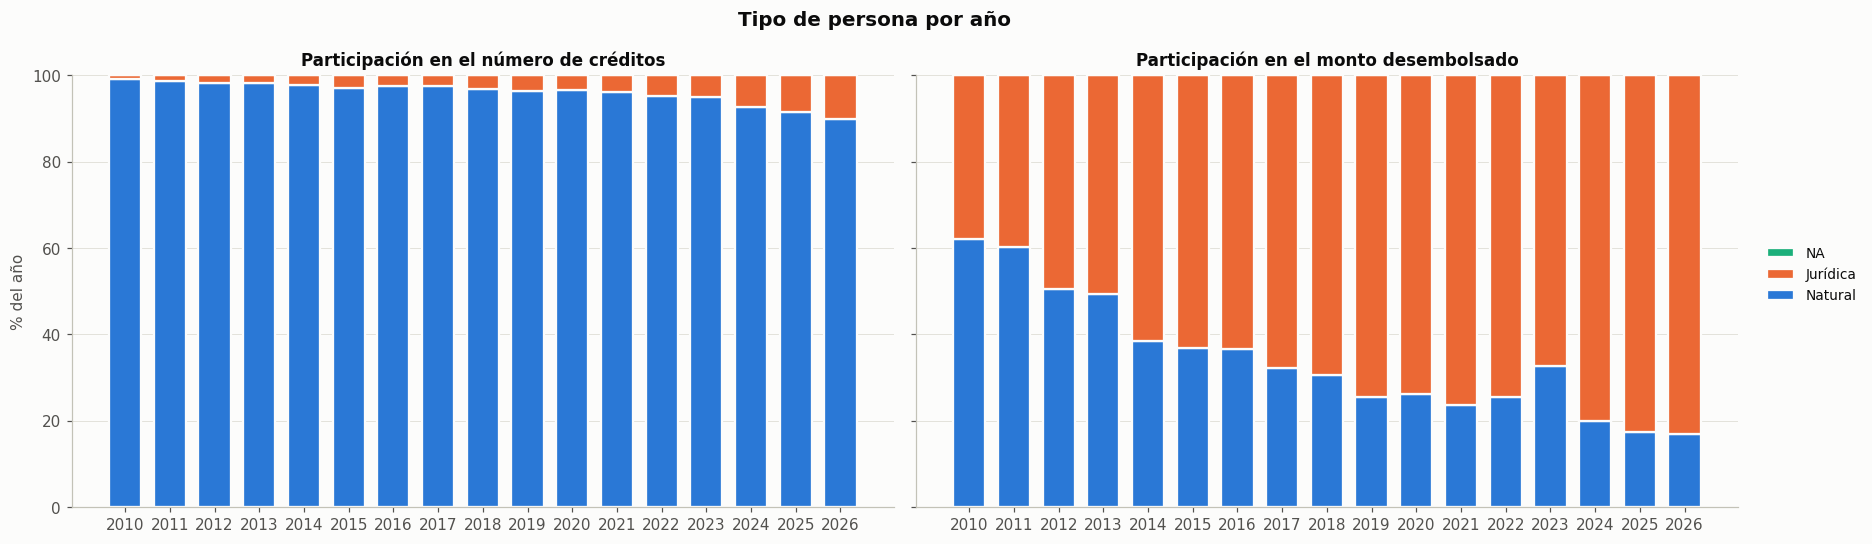

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_persona,,,,,,,,,,,,,,,,,
Natural,246.7,271.0,262.5,273.2,239.5,220.1,303.5,433.9,402.1,398.2,495.6,461.3,474.8,506.9,366.0,362.3,193.9
Jurídica,2.5,4.0,4.9,4.8,5.5,6.9,7.5,11.6,12.9,15.5,17.6,18.7,24.4,26.6,29.0,33.3,21.9
NA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_persona,,,,,,,,,,,,,,,,,
Natural,99.0,98.6,98.2,98.3,97.8,97.0,97.6,97.4,96.9,96.3,96.6,96.1,95.1,95.0,92.7,91.6,89.8
Jurídica,1.0,1.4,1.8,1.7,2.2,3.0,2.4,2.6,3.1,3.7,3.4,3.9,4.9,5.0,7.3,8.4,10.1
NA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
tipo_persona,,,,,,,,,,,,,,,,,
Natural,"2,600","3,300","3,270","3,433","3,116","3,124","3,812","4,749","4,679","4,897","6,338","6,481","7,307","8,095","7,858","8,362","4,342"
Jurídica,"1,582","2,173","3,201","3,529","4,997","5,362","6,573","10,027","10,585","14,352","17,873","20,981","21,297","16,660","31,586","39,720","21,378"
NA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


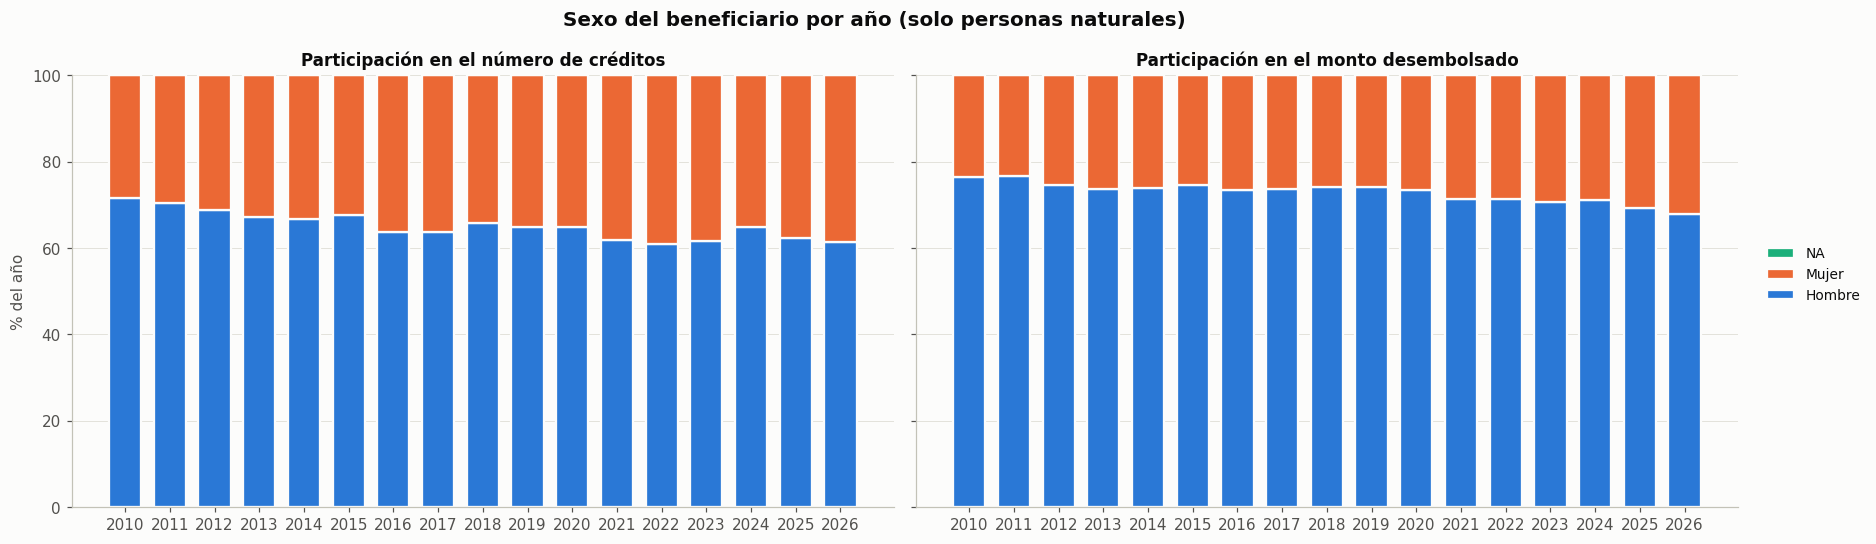

anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
sexo,,,,,,,,,,,,,,,,,
Hombre,71.5,70.3,68.8,67.1,66.8,67.7,63.8,63.7,65.8,64.9,64.8,61.8,60.8,61.7,64.9,62.3,61.5
Mujer,28.5,29.7,31.2,32.9,33.2,32.3,36.2,36.3,34.2,35.1,35.2,38.2,39.2,38.3,35.1,37.7,38.5
NA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Tipo de persona y, para personas naturales, sexo
_ = figura_por_anio("tipo_persona", "Tipo de persona por año")

nat = fin[fin["tipo_persona"].astype("object").eq("Natural")]
sexo = etiquetas(nat["sexo"])
sexo_n = pd.crosstab(sexo, nat["anio"])
sexo_m = nat["valor_credito"].groupby([sexo, nat["anio"]]).sum().unstack(fill_value=0) / MMM
orden = sexo_n.sum(axis=1).sort_values(ascending=False).index
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
apiladas(a1, sexo_n.loc[orden], "Participación en el número de créditos")
apiladas(a2, sexo_m.loc[orden], "Participación en el monto desembolsado", ylabel="")
h, l = a1.get_legend_handles_labels()
fig.legend(h[::-1], l[::-1], loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
fig.suptitle("Sexo del beneficiario por año (solo personas naturales)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()
del nat, sexo
participacion(sexo_n.loc[orden]).style.format("{:.1f}")

In [27]:
# Cruce productor x beneficiario: que poblaciones especiales hay dentro de cada tamaño de productor (todo el periodo)
cruce = pd.crosstab(etiquetas(fin["tipo_beneficiario"]), etiquetas(fin["tipo_productor"]))
cruce = cruce.loc[cruce.sum(axis=1).sort_values(ascending=False).index,
                  cruce.sum(axis=0).sort_values(ascending=False).index]
(cruce / 1e3).style.format("{:,.1f}").set_caption("Créditos (miles) por tipo de beneficiario y tipo de productor")

tipo_productor,Pequeño,Mediano,Pequeño ppib,Grande,Pequeño ingresos bajos,No aplica
tipo_beneficiario,,,,,,
Pequeño productor,"3,309.6",0.0,0.0,0.0,0.0,0.0
Mediano productor,0.0,870.5,0.0,0.0,0.0,0.0
Pequeño productor de ingresos bajos,0.0,0.0,517.5,0.0,46.1,0.0
Microempresario pequeño,469.9,0.0,0.0,0.0,0.0,0.0
Grande productor,0.0,0.0,0.0,191.1,0.0,0.0
Desplazados p.p,156.3,0.0,0.0,0.0,0.0,0.0
Mujer rural ppib,0.0,0.0,139.8,0.0,8.0,0.0
Desplazado ppib,0.0,0.0,118.1,0.0,10.7,0.0
Mujer rural,88.1,0.0,0.0,0.0,0.0,0.0


**Lectura:**
- **Cambios de clasificación:** en 2023 aparece "Pequeño ppib" (pequeño productor de ingresos bajos), que absorbe buena parte de lo que antes era "Pequeño". En 2026 aparecen "Pequeño ingresos bajos" y "No aplica". También "Microempresario pequeño" existe solo entre 2018 y 2023. Son cambios en cómo se clasifica, no en quién recibe el crédito. Por eso la tendencia se lee con los pequeños agrupados.
- **Pequeños y grandes:** los pequeños productores son la gran mayoría de los desembolsos, cerca del 86 % hasta 2022 y alrededor del 79 % en 2024–2025. Los grandes pasaron del 0,4 % de los desembolsos (2010) al 9,3 % (2026), y su participación en el monto subió del 24 % al 74 %. **En número el crédito es de pequeños productores; en dinero es de grandes.**
- **Tipo de persona:** las personas jurídicas pasaron del 1 % al 10 % de los desembolsos y del 38 % al 83 % del monto.
- **Sexo (personas naturales):** la participación de las mujeres subió del 28,5 % (2010) al 38,5 % (2026).
- **Poblaciones especiales:** los desplazados, las víctimas del conflicto y la mujer rural ganan visibilidad desde 2018 y, sobre todo, desde 2023, cuando la clasificación empieza a separarlos.

### 2.5 Qué materia prima se financia

- **`cadena`:** cadena productiva (café, ganadería bovina, arroz, palma…).
- **`eslabon_cadena`:** en qué parte de la cadena está la actividad (producción, transformación, comercialización…).
- **`Nombre_destino`:** el destino específico del crédito dentro de la cadena. Por ejemplo, "Plátano" o "Arroz riego".

In [28]:
import unicodedata

# En 2026 FINAGRO cambio el catalogo de cadenas: los nombres vienen con tildes y minusculas ("Caña de azúcar" en vez de
# "Caña de Azucar"), algunos cambian ("Ganadería doble propósito" = "Ganado DP") y aparecen cadenas mas detalladas
# (Tomate, Mora, Lulo...). Se unifica la escritura y los renombres evidentes para comparar entre años.
def sin_tildes(s):
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower().strip()


RENOMBRES_2026 = {"ganaderia doble proposito": "ganado dp", "ganaderia carne": "ganado carne",
                  "acuicultura y pesca": "pesquero y acuicola", "yuca y name": "yuca"}
etiquetas_cadena = pd.Series(fin["cadena"].cat.categories)
clave = etiquetas_cadena.map(sin_tildes).replace(RENOMBRES_2026)
frecuencia = fin["cadena"].value_counts()
nombre = {k: max(g, key=lambda c: frecuencia[c])  # se muestra la escritura mas frecuente
          for k, g in etiquetas_cadena.groupby(clave.values).apply(list).items()}
unificar = dict(zip(etiquetas_cadena, clave.map(nombre)))
fin["cadena_h"] = fin["cadena"].astype("object").map(unificar).astype("category")

print(f"{fin['cadena'].nunique()} etiquetas de cadena -> {fin['cadena_h'].nunique()} cadenas después de unificar")
unidas = pd.Series(unificar)[lambda s: s.index != s.values]
pd.DataFrame({"etiqueta original": unidas.index, "se une con": unidas.values})

80 etiquetas de cadena -> 61 cadenas después de unificar


,etiqueta original,se une con
0,Actividades complementarias,Actividades Complementarias
1,Otros frutales,Otros Frutales
2,Otros cultivos,Otros Cultivos
3,Ganadería leche,Ganaderia Leche
4,Ganadería carne,Ganado Carne
5,Ganadería doble propósito,Ganado DP
6,Caña panelera,Caña Panelera
7,Plátano,Platano
8,Caña de azúcar,Caña de Azucar
9,Yuca y ñame,Yuca


61 cadenas. Las 20 con más desembolsos cubren 94.4% de los desembolsos; las 20 con más monto cubren 92.7% del monto


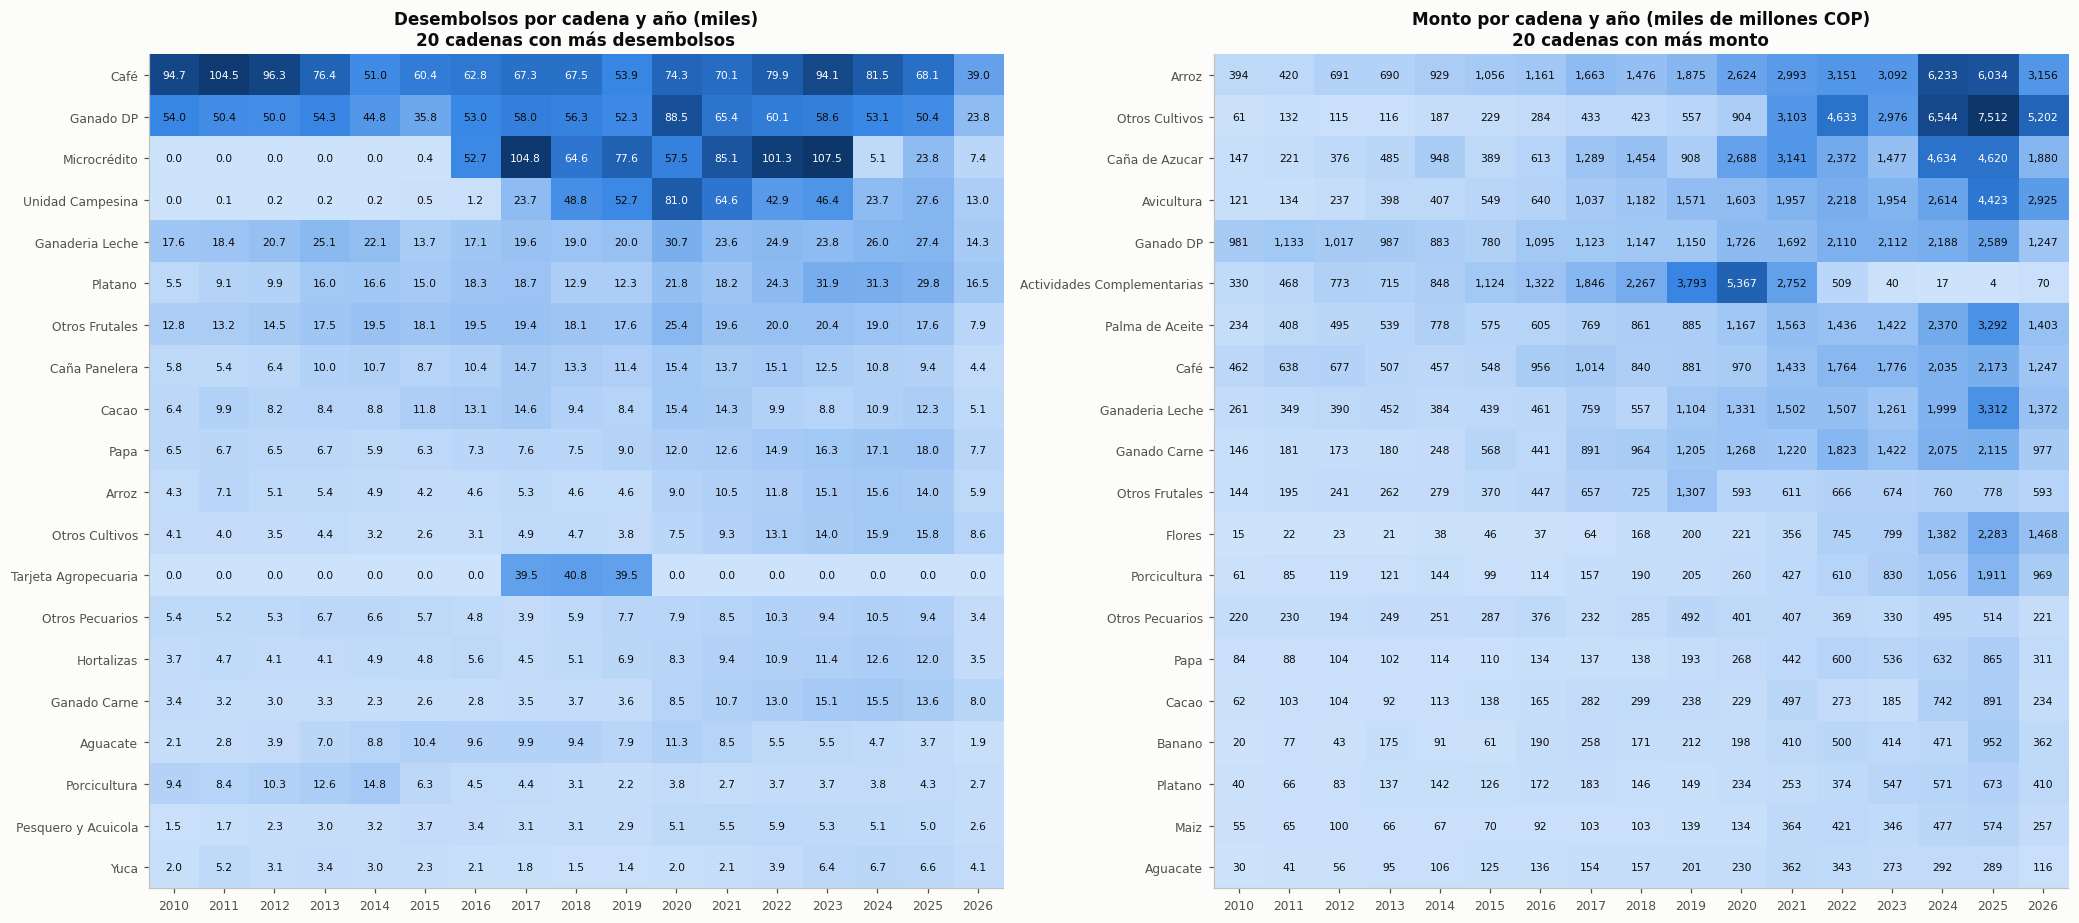

,desembolsos,monto (miles de millones COP),% desembolsos,% monto,crédito mediano (millones COP)
cadena_h,,,,,
Arroz,"131,898","37,638",2.1,11.8,30.0
Otros Cultivos,"122,660","33,412",2.0,10.5,12.0
Caña de Azucar,"19,509","27,640",0.3,8.7,70.0
Avicultura,"46,147","23,971",0.7,7.5,40.0
Ganado DP,"908,794","23,960",14.8,7.5,10.7
Actividades Complementarias,"51,216","22,247",0.8,7.0,55.0
Palma de Aceite,"26,777","18,801",0.4,5.9,100.0
Café,"1,241,784","18,376",20.2,5.8,6.0
Ganaderia Leche,"363,705","17,439",5.9,5.5,10.5


In [29]:
# Cadenas: el numero de desembolsos y el monto se concentran en cadenas distintas, asi que se hacen dos rankings
cad = etiquetas(fin["cadena_h"])
cad_n = pd.crosstab(cad, fin["anio"])
cad_m = fin["valor_credito"].groupby([cad, fin["anio"]]).sum().unstack(fill_value=0) / MMM
top_n = cad_n.sum(axis=1).sort_values(ascending=False).index[:20]
top_m = cad_m.sum(axis=1).sort_values(ascending=False).index[:20]
print(f"{fin['cadena_h'].nunique()} cadenas. Las 20 con más desembolsos cubren "
      f"{cad_n.loc[top_n].values.sum() / cad_n.values.sum():.1%} de los desembolsos; "
      f"las 20 con más monto cubren {cad_m.loc[top_m].values.sum() / cad_m.values.sum():.1%} del monto")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(19, 8.5))
mapa_calor(a1, cad_n.loc[top_n] / 1e3, "Desembolsos por cadena y año (miles)\n20 cadenas con más desembolsos",
           fmt="{:,.1f}")
mapa_calor(a2, cad_m.loc[top_m], "Monto por cadena y año (miles de millones COP)\n20 cadenas con más monto",
           fmt="{:,.0f}")
fig.tight_layout()
plt.show()

resumen_cad = pd.DataFrame({"desembolsos": cad_n.sum(axis=1),
                            "monto (miles de millones COP)": cad_m.sum(axis=1)})
resumen_cad["% desembolsos"] = resumen_cad["desembolsos"] / resumen_cad["desembolsos"].sum() * 100
resumen_cad["% monto"] = resumen_cad["monto (miles de millones COP)"] / resumen_cad["monto (miles de millones COP)"].sum() * 100
resumen_cad["crédito mediano (millones COP)"] = fin["valor_credito"].groupby(cad).median() / 1e6
(resumen_cad.sort_values("monto (miles de millones COP)", ascending=False).head(25)
 .style.format({"desembolsos": "{:,.0f}", "monto (miles de millones COP)": "{:,.0f}", "% desembolsos": "{:.1f}",
                "% monto": "{:.1f}", "crédito mediano (millones COP)": "{:,.1f}"})
 .set_caption("Las 25 cadenas con más monto (todo el periodo)"))

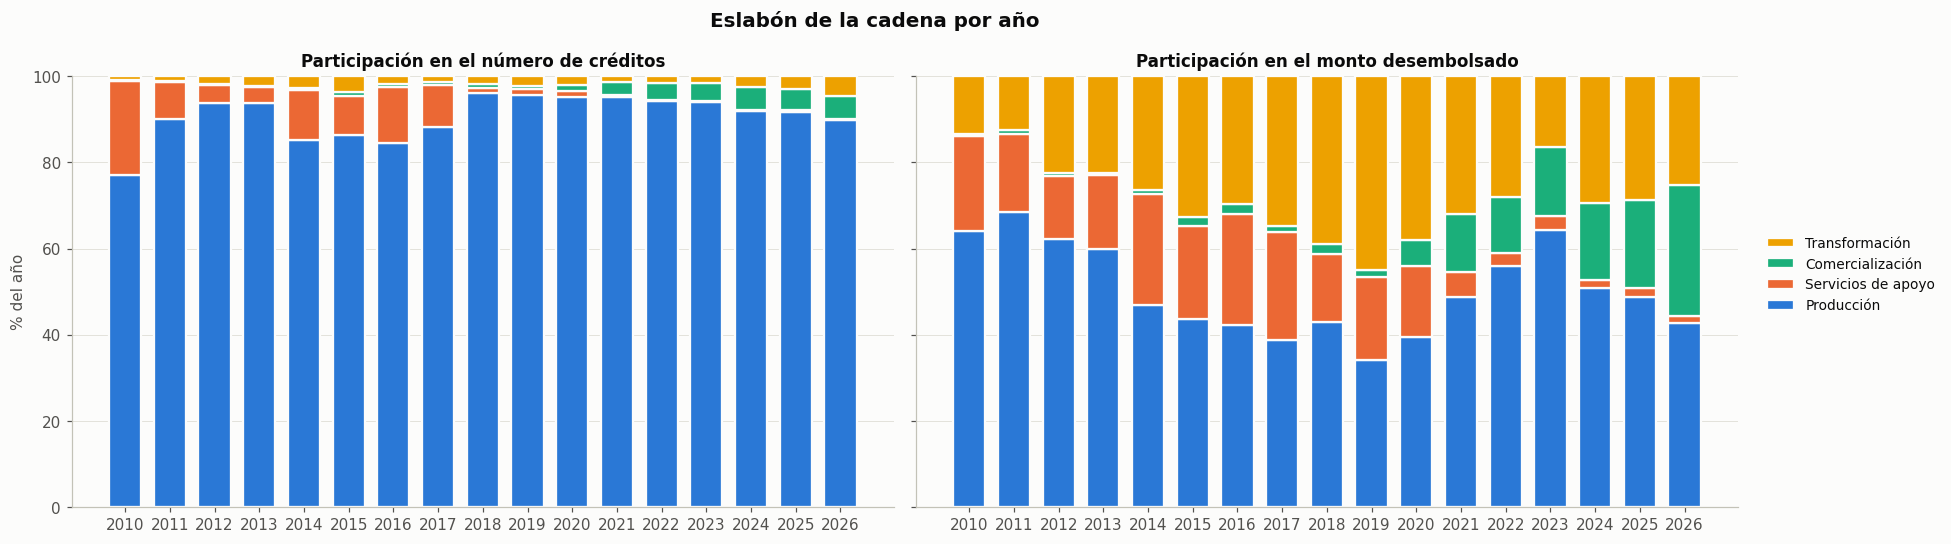

Número de créditos (miles)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
eslabon_cadena,,,,,,,,,,,,,,,,,
Producción,192.2,247.7,250.4,260.5,208.7,195.9,262.7,393.4,399.0,395.6,489.0,456.9,470.1,501.1,362.6,362.8,193.7
Servicios de apoyo,53.9,23.3,11.5,10.3,28.4,20.5,40.5,43.2,4.7,5.5,6.2,2.4,1.7,1.3,1.0,1.3,0.7
Comercialización,0.6,0.6,0.8,1.2,1.2,2.4,2.5,2.5,3.5,3.6,7.7,13.8,19.3,22.8,21.2,19.9,11.6
Transformación,2.4,3.3,4.6,6.1,6.6,8.1,5.3,6.4,7.8,9.1,10.4,6.8,8.1,8.4,10.1,11.6,9.8


Participación en el número de créditos (%)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
eslabon_cadena,,,,,,,,,,,,,,,,,
Producción,77.1,90.1,93.7,93.7,85.2,86.3,84.5,88.3,96.1,95.6,95.3,95.2,94.2,93.9,91.8,91.7,89.8
Servicios de apoyo,21.6,8.5,4.3,3.7,11.6,9.0,13.0,9.7,1.1,1.3,1.2,0.5,0.3,0.2,0.3,0.3,0.3
Comercialización,0.3,0.2,0.3,0.4,0.5,1.1,0.8,0.6,0.8,0.9,1.5,2.9,3.9,4.3,5.4,5.0,5.4
Transformación,1.0,1.2,1.7,2.2,2.7,3.6,1.7,1.4,1.9,2.2,2.0,1.4,1.6,1.6,2.6,2.9,4.5


Monto desembolsado (miles de millones de COP)


anio,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
eslabon_cadena,,,,,,,,,,,,,,,,,
Producción,"2,685","3,745","4,031","4,164","3,815","3,712","4,388","5,719","6,560","6,591","9,581","13,405","16,030","15,897","20,067","23,442","10,979"
Servicios de apoyo,913,998,942,"1,195","2,086","1,822","2,683","3,717","2,413","3,712","3,997","1,612",832,845,703,"1,009",426
Comercialización,25,43,42,47,64,183,231,202,365,289,"1,415","3,637","3,727","3,959","7,116","9,803","7,795"
Transformación,559,687,"1,456","1,556","2,147","2,770","3,084","5,137","5,927","8,657","9,218","8,808","8,015","4,053","11,558","13,829","6,521"


,créditos,monto (miles de millones COP),% créditos,% monto
Nombre_destino,,,,
Sin dato,"1,235,974","96,912",20.1,30.5
Vientres bovinos y bufalinos comerciales cría y D.P,"672,332","12,131",10.9,3.8
Capital de trabajo Unidad Productiva Campesina,"420,785","1,824",6.8,0.6
Café,"320,547","3,292",5.2,1.0
Sostenimiento café,"304,735","2,492",4.9,0.8
Vientres bovinos comerciales leche,"291,649","4,592",4.7,1.4
Plátano,"238,249","2,949",3.9,0.9
Renovación cafetales envejecidos,"191,172","1,028",3.1,0.3
Papa,"146,780","2,652",2.4,0.8


In [30]:
_ = figura_por_anio("eslabon_cadena", "Eslabón de la cadena por año")

# Destinos especificos: los 20 con mas creditos en todo el periodo
dest = fin.groupby(etiquetas(fin["Nombre_destino"])).agg(creditos=("valor_credito", "size"),
                                                         monto=("valor_credito", "sum"))
dest["monto"] /= MMM
dest["% créditos"] = dest["creditos"] / dest["creditos"].sum() * 100
dest["% monto"] = dest["monto"] / dest["monto"].sum() * 100
(dest.sort_values("creditos", ascending=False).head(20)
 .rename(columns={"creditos": "créditos", "monto": "monto (miles de millones COP)"})
 .style.format({"créditos": "{:,.0f}", "monto (miles de millones COP)": "{:,.0f}",
                "% créditos": "{:.1f}", "% monto": "{:.1f}"})
 .set_caption("Los 20 destinos con más créditos (todo el periodo)"))

**Lectura:**
- **Cambio de catálogo en 2026:** las etiquetas de `cadena` cambian en 2026, así que antes de comparar años hay que unificarlas, como se hace arriba. Además, en 2026 aparecen cadenas más detalladas (Tomate, Mora, Lulo, Cebolla…) que antes estaban dentro de "Otros frutales" u "Otros cultivos". Por eso las participaciones de esas categorías en 2026 no son comparables con las de años anteriores.
- **Por número de desembolsos** dominan el café (20 %), el ganado doble propósito (15 %) y el microcrédito (11 %), seguidos de la unidad campesina, la ganadería de leche, el plátano y los frutales. Las cadenas ganaderas (doble propósito, leche y carne) suman el 22,5 % de los desembolsos y el 18 % del monto, lo que interesa para el vínculo con la deforestación.
- **Por monto** el orden cambia por completo. Lideran el arroz (11,8 %), "otros cultivos" (10,5 %), la caña de azúcar (8,7 %), la avicultura (7,5 %), el ganado doble propósito (7,5 %), las actividades complementarias (7,0 %), la palma de aceite (5,9 %) y el café (5,8 %). Son cadenas agroindustriales con créditos grandes. Las actividades complementarias casi desaparecen entre 2022 y 2025 y reaparecen en 2026, otra señal de cambios de clasificación.
- **Productos financieros:** Microcrédito, Unidad Campesina, Tarjeta Agropecuaria (2017–2019) y Actividades Complementarias no dicen qué materia prima se financia. Para eso sirve `Nombre_destino`, aunque está vacío en el 20 % de las filas.
- **Eslabón:** casi todos los desembolsos (92 %) financian la producción primaria. En monto, en cambio, la comercialización pasó del 0,6 % (2010) al 30 % (2026) y la transformación ronda entre el 13 % y el 45 %.
- **Destinos específicos:** los más frecuentes son los vientres bovinos de cría y doble propósito (10,9 %), el capital de trabajo de la unidad productiva campesina, el café (siembra, sostenimiento y renovación) y los vientres de leche.

## Resumen

1. **Qué es cada fila:** la tabla tiene 6,16 millones de **desembolsos** de crédito agropecuario con respaldo de FINAGRO, entre enero de 2010 y junio de 2026 (2026 incompleto), en unos 1.100 municipios por año.
2. **Número frente a dinero:** hay dos historias distintas. En número de desembolsos, el crédito es de pequeños productores y personas naturales, de café y ganadería, y va a municipios intermedios y rurales. En dinero, se concentra en grandes productores y empresas, en crédito de capital de trabajo con cartera sustitutiva, en cadenas agroindustriales (arroz, caña, avicultura, palma) y en ciudades como Bogotá, Medellín y Cali.
3. **Tendencia:** el número de desembolsos creció hasta 2023 y luego bajó. El monto nominal sigue creciendo, así que cada crédito es más grande.
4. **Cuidados antes de usar la tabla:**
   - `id_credito` no es único.
   - Las clasificaciones cambian en el tiempo: el tipo de productor en 2023 y 2026, el catálogo de cadenas en 2026 y la tasa de DTF a IBR en 2019–2021.
   - `valor_subsidio` viene como texto.
   - Hay valores atípicos en `periodo_gracia`, `puntos_adicionales` y `tasa_total`.
   - El municipio del crédito puede ser el domicilio del deudor y no el lugar de la producción.